# Promoter pausing and accessibility analysis 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
import pysam
import pyBigWig
from collections import defaultdict
import os
import os

the tss accessibility table is located at `/project/spott/cshan/fiber-seq/results/PolII/m6a_pausing_quartiles/AL10_bc2178_19130_1kb_bin10_modthresh0.9_all/tables/AL10_bc2178_19130_tss_read_accessibility.tsv.gz`
- the code used to create this table is located at `/project/spott/cshan/fiber-seq/code/PolII_footprints_code/m6a_pausing_quartiles`

In [1]:
%%bash

less /project/spott/cshan/fiber-seq/results/PolII/m6a_pausing_quartiles/AL10_bc2178_19130_1kb_bin10_modthresh0.9_all/tables/AL10_bc2178_19130_tss_read_accessibility.tsv.gz | head

read_id	tss_uid	gene_id	gene_id_base	gene_name	chromosome	tss_coordinate	tss_strand	tss_source	PI	pausing_group	n_positions_covered	n_m6a_modified	n_m6a_unmodified	tss_accessible
AL10_bc2178_19130-m84241_250311_201728_s2/64488132/ccs	chr1|6206118|+|ENSG00000158286|185	ENSG00000158286.14	ENSG00000158286	RNF207	chr1	6206118	+	CAGE	7.99178294573734	Q4 (High PI)	60	15	23	TRUE
AL10_bc2178_19130-m84241_250311_201728_s2/125570575/ccs	chr1|6206118|+|ENSG00000158286|185	ENSG00000158286.14	ENSG00000158286	RNF207	chr1	6206118	+	CAGE	7.99178294573734	Q4 (High PI)	60	8	14	TRUE
AL10_bc2178_19130-m84241_250311_201728_s2/218368972/ccs	chr1|6206118|+|ENSG00000158286|185	ENSG00000158286.14	ENSG00000158286	RNF207	chr1	6206118	+	CAGE	7.99178294573734	Q4 (High PI)	60	8	14	TRUE
AL10_bc2178_19130-m84241_250311_201728_s2/219547243/ccs	chr1|6206118|+|ENSG00000158286|185	ENSG00000158286.14	ENSG00000158286	RNF207	chr1	6206118	+	CAGE	7.99178294573734	Q4 (High PI)	60	0	22	FALSE
AL10_bc2178_19130-m84241_250311_2017

This table contains one row per read-TSS pair, summarizing the m6A modification status of adenines within ±100 bp of the TSS for each read. It includes the following columns:

| Column | Description | Example Value | Type |
|--------|-------------|----------------|------|
| `read_id` | Unique identifier for the sequenced read (PacBio CCS) | `AL10_bc2178_19130-m84241_250311_201728_s2/64488132/ccs` | string |
| `tss_uid` | Unique TSS identifier built as chr\|tss_coord\|strand\|gene_id\|row_id | `chr1\|6206118\|+\|ENSG00000158286\|185` | string |
| `gene_id` | GENCODE gene identifier with version suffix | `ENSG00000158286.14` | string |
| `gene_id_base` | GENCODE gene identifier without version suffix | `ENSG00000158286` | string |
| `gene_name` | HGNC gene symbol | `RNF207` | string |
| `chromosome` | Genomic chromosome | `chr1` | string |
| `tss_coordinate` | Transcription start site position (1-based) | `6206118` | integer |
| `tss_strand` | Strand orientation of the gene | `+` | string (+/-) |
| `tss_source` | TSS source: CAGE or GENCODE | `CAGE` | string |
| `PI` | Pol II pausing index (higher = more paused) | `7.99178294573734` | float |
| `pausing_group` | Quartile assignment based on PI | `Q4 (High PI)` | string (Q1-Q4) |
| `n_positions_covered` | Number of adenine positions covered by this read within ±100 bp of TSS | `60` | integer |
| `n_m6a_modified` | Number of m6A-modified adenines detected in this read within ±100 bp of TSS | `15` | integer |
| `n_m6a_unmodified` | Number of unmodified adenines detected in this read within ±100 bp of TSS | `23` | integer |
| `tss_accessible` | Boolean: TRUE if ≥1 m6A call in ±100 bp window (chromatin open), FALSE if 0 m6A calls (protected/inaccessible) | `TRUE` | boolean |

**Key points:**
- Each row = one read's experience at one TSS
- `n_positions_covered` = `n_m6a_modified` + `n_m6a_unmodified` (all called adenines in the ±100 bp window)
- `tss_accessible = TRUE` when a read carries m6A evidence near the TSS; `FALSE` means the region was inaccessible or protected from methylation


# table for footprint midpoints
example table at: `/project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr1_footprints.bed.gz`
- the code used to create this table is located at `/project/spott/cshan/fiber-seq/code/PolII_footprints_code/footprints_summary_code`

In [2]:
%%bash

less /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr1_footprints.bed.gz | head -n 10

chr1	10000	10018	m84241_250909_000942_s2/264508392/ccs	FIRE_nucleosome	10009.0
chr1	10000	10020	m84241_250908_220650_s1/250481348/ccs	FIRE_nucleosome	10010.0
chr1	10000	10024	m84241_250326_031141_s3/130221495/ccs	FIRE_nucleosome	10012.0
chr1	10000	10030	m84241_250514_222554_s2/266278306/ccs	FIRE_nucleosome	10015.0
chr1	10000	10044	m84241_250326_010847_s2/18220681/ccs	FIRE_nucleosome	10022.0
chr1	10000	10048	m84241_250906_015218_s2/106303285/ccs	FIRE_nucleosome	10024.0
chr1	10000	10050	m84241_250908_200356_s4/54790654/ccs	FIRE_nucleosome	10025.0
chr1	10000	10056	m84241_250326_010847_s2/156568420/ccs	FIRE_nucleosome	10028.0
chr1	10000	10056	m84241_250906_015218_s2/215484369/ccs	FIRE_nucleosome	10028.0
chr1	10000	10062	m84241_250905_234909_s1/164431819/ccs	FIRE_nucleosome	10031.0


# For reads that have accessibility at TSS (+/- 100 bp), how many nucleosome/PPP footprints do they have within 1 kb of the TSS?

1. First, I want to merge the footprint summary files for nucleosomes called by FIRE. The files are separated by chromosomes at `/project/spott/cshan/fiber-seq/results/PolII/footprint_summaries/FIRE_nucleosome`

In [5]:
%%bash

cat << 'EOF' > /project/spott/cshan/fiber-seq/code/PolII_footprints_code/accessibility_pausing_code/merge_FIRE_nucleosome.sh
#!/bin/bash

#SBATCH --job-name=merge_FIRE_nuc
#SBATCH --account=pi-spott
#SBATCH --partition=caslake
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=1
#SBATCH --mem=100G
#SBATCH --time=12:00:00
#SBATCH --output=/project/spott/cshan/fiber-seq/results/logs/merge_FIRE_nuc_%j.out
#SBATCH --error=/project/spott/cshan/fiber-seq/results/logs/merge_FIRE_nuc_%j.err


INPUT_DIR="/project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome"
OUTPUT_FILE="${INPUT_DIR}/merged_footprint_summary.tsv.gz"

echo "Starting merge at $(date)"

cd "$INPUT_DIR"

# create header
echo -e "chrom\tstart\tend\tread_id\tclass\tmidpoint" | gzip > "$OUTPUT_FILE"

# append all files (skip headers since BED doesn't have one)
for f in *.bed.gz; do
    echo "Processing $f"
    zcat "$f" >> temp_merged.tsv
done

# compress final
gzip -c temp_merged.tsv >> "$OUTPUT_FILE"

# cleanup
rm temp_merged.tsv

echo "Finished at $(date)"
EOF

In [6]:
!chmod +x /project/spott/cshan/fiber-seq/code/PolII_footprints_code/accessibility_pausing_code/merge_FIRE_nucleosome.sh

In [1]:
!sbatch /project/spott/cshan/fiber-seq/code/PolII_footprints_code/accessibility_pausing_code/merge_FIRE_nucleosome.sh

sbatch: Verify job submission ...
sbatch: Using a shared partition ...
sbatch: Partition: caslake
sbatch: QOS-Flag: caslake
sbatch: Account: pi-spott
sbatch: Verification: ***PASSED***
Submitted batch job 49373033


In [ ]:
%%bash

#  merged FIRE nucleosome
less /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/merged_footprint_summary.tsv.gz | head -n 10


In [2]:
!sbatch /project/spott/cshan/fiber-seq/code/PolII_footprints_code/accessibility_pausing_code/submit_count_accessible_tss_FIRE_nucleosomes_1kb.sh

sbatch: Verify job submission ...
sbatch: Using a shared partition ...
sbatch: Partition: caslake
sbatch: QOS-Flag: caslake
sbatch: Account: pi-spott
sbatch: Verification: ***PASSED***
Submitted batch job 49373055


In [ ]:
%%bash

module load R

Rscript - <<'RSCRIPT'
library(data.table)
library(ggplot2)

out_dir <- "/project/spott/cshan/fiber-seq/results/PolII/m6a_pausing_quartiles/AL10_bc2178_19130_1kb_bin10_modthresh0.9_all/tss_accessible_FIRE_nucleosome_1kb"
counts_file <- file.path(out_dir, "accessible_tss_read_FIRE_nucleosome_counts_1kb.tsv.gz")
counts <- fread(counts_file)

counts[, pausing_group := factor(
  pausing_group,
  levels = c("Q1 (Low PI)", "Q2", "Q3", "Q4 (High PI)")
)]

p <- ggplot(counts, aes(x = pausing_group, y = n_footprints_1kb, fill = pausing_group)) +
  geom_violin(trim = FALSE, scale = "width", color = "gray25", linewidth = 0.25) +
  geom_boxplot(width = 0.16, outlier.size = 0.35, color = "gray20", fill = "white", alpha = 0.82) +
  stat_summary(fun = median, geom = "point", size = 1.4, color = "black") +
  scale_fill_manual(values = c(
    "Q1 (Low PI)" = "#4C78A8",
    "Q2" = "#59A14F",
    "Q3" = "#F28E2B",
    "Q4 (High PI)" = "#E15759"
  ), na.value = "gray70") +
  labs(
    x = "Pausing group",
    y = "FIRE nucleosome footprints within TSS +/- 1 kb",
    title = "Accessible TSS reads: FIRE nucleosome footprint counts near TSS"
  ) +
  theme_classic(base_size = 12) +
  theme(
    legend.position = "none",
    axis.text.x = element_text(angle = 25, hjust = 1),
    plot.title = element_text(face = "bold")
  )

ggsave(file.path(out_dir, "accessible_tss_read_FIRE_nucleosome_counts_1kb_by_pausing_group_violin.png"), p, width = 7.2, height = 4.8, dpi = 300)
ggsave(file.path(out_dir, "accessible_tss_read_FIRE_nucleosome_counts_1kb_by_pausing_group_violin.pdf"), p, width = 7.2, height = 4.8)

cat("Wrote violin plot PNG/PDF to ", out_dir, "\n", sep = "")
RSCRIPT


In [ ]:
%%bash

out_dir="/project/spott/cshan/fiber-seq/results/PolII/m6a_pausing_quartiles/AL10_bc2178_19130_1kb_bin10_modthresh0.9_all/tss_accessible_FIRE_nucleosome_1kb"

ls -lh "$out_dir"
echo
echo "Pausing-group summary:"
column -t -s $'\t' "$out_dir/accessible_read_FIRE_nucleosome_counts_by_pausing_group.tsv"
echo
echo "First per-TSS rows:"
head -n 10 "$out_dir/accessible_read_FIRE_nucleosome_counts_by_tss.tsv"


### Quartile-based gene selection

Per-gene PI distribution from
`/project/spott/cshan/fiber-seq/results/PolII/annotations/pausing_index_principal_with_CAGE_TSS_all_genes.tsv`.

1. keep CAGE-supported genes only (`cage_tss` not null)
2. dedupe to one row per gene (highest-PI transcript)
3. split into quartiles Q1..Q4 on per-gene PI
4. take the **top 100 by PI within each quartile** -> 400 genes total

1. extract selected genes from PI table

In [3]:
# Load PI table, filter for CAGE-supported, dedupe to highest-PI transcript per gene,
# assign quartiles, take top 100 by PI within each quartile.
pi_path = "/project/spott/cshan/fiber-seq/results/PolII/annotations/pausing_index_principal_with_CAGE_TSS_all_genes.tsv"
pi_tbl = pd.read_csv(pi_path, sep="\t")

# Treat empty strings in cage_tss as missing
pi_tbl["cage_tss"] = pd.to_numeric(pi_tbl["cage_tss"], errors="coerce")
pi_tbl = pi_tbl.dropna(subset=["cage_tss"]).copy()

# Highest-PI transcript per gene
pi_tbl = (
    pi_tbl.sort_values("PI", ascending=False)
          .drop_duplicates(subset="gene_name")
          .reset_index(drop=True)
)

# Quartile assignment on per-gene PI
pi_tbl["pi_quartile"] = pd.qcut(pi_tbl["PI"], 4, labels=["Q1", "Q2", "Q3", "Q4"])

# Top 100 by PI within each quartile
TOP_N = 100
selected = (
    # sort by descending PI, then take top N per quartile
    pi_tbl.sort_values("PI", ascending=False)
          .groupby("pi_quartile", observed=True)
          .head(TOP_N)
          .reset_index(drop=True)
)

print(f"CAGE-supported genes (highest-PI transcript): {len(pi_tbl):,}")
print()
print("Selected per quartile:")
print(
    selected.groupby("pi_quartile", observed=True)["PI"]
    .agg(n="count", min_PI="min", max_PI="max")
    .reset_index()
    .to_string(index=False)
)

CAGE-supported genes (highest-PI transcript): 6,519

Selected per quartile:
pi_quartile   n    min_PI    max_PI
         Q1 100  2.013898  2.154380
         Q2 100  4.454199  4.622356
         Q3 100  7.865102  8.125864
         Q4 100 18.534784 37.888792


In [4]:
# Per-quartile gene lists, lookups, and quartile colour map.
quartiles = ["Q1", "Q2", "Q3", "Q4"]

# dictionary mapping quartiles to lists of gene names in that quartile
quartile_to_genes = {
    # loop over quartiles and extract gene names for each
    q: selected.loc[selected["pi_quartile"] == q, "gene_name"].tolist()
    for q in quartiles
}
gene_to_quartile = dict(zip(selected["gene_name"], selected["pi_quartile"].astype(str)))
all_selected = selected["gene_name"].tolist()

# Gradient: Q1 (low PI) -> Q4 (high PI)
quartile_colors = {
    "Q1": "#4C78A8",
    "Q2": "#9CC2E5",
    "Q3": "#F4A582",
    "Q4": "#E15759",
}

print({q: len(g) for q, g in quartile_to_genes.items()})

{'Q1': 100, 'Q2': 100, 'Q3': 100, 'Q4': 100}


In [5]:
# Read accessibility parquet (only the columns + selected genes we need so it fits in memory).
# Also load n_positions_covered / n_m6a_modified / n_m6a_unmodified so we can recompute
# accessibility with a configurable m6A-fraction threshold below.
cols = [
    "gene_name",
    "tss_accessible",
    "read_id",
    "chromosome",
    "tss_coordinate",
    "tss_strand",
    "PI",
    "n_positions_covered",
    "n_m6a_modified",
    "n_m6a_unmodified",
]

accessibility_df = pd.read_parquet(
    "/project/spott/cshan/fiber-seq/results/PolII/m6a_pausing_quartiles/AL10_bc2178_19130_1kb_bin10_modthresh0.9_all/tables/AL10_bc2178_19130_tss_read_accessibility.parquet",
    columns=cols,
    filters=[("gene_name", "in", all_selected)],
    dtype_backend="pyarrow",
)

n_found = accessibility_df["gene_name"].nunique()
print(f"Loaded {len(accessibility_df):,} rows for {n_found} of {len(all_selected)} selected genes "
      f"({len(all_selected) - n_found} not present in the accessibility parquet)")

Loaded 1,543,453 rows for 400 of 400 selected genes (0 not present in the accessibility parquet)


## Footprint distribution analysis across PI quartiles

For the 400 selected genes (100 per quartile), we analyze:
1. Number of FIRE nucleosome footprints per accessible read within TSS +/- 1 kb
2. Spatial distribution of footprint midpoints relative to TSS

In [6]:
# Restrict to reads whose alignment fully spans TSS +/- TSS_SPAN_HALF bp.
# Spans are re-derived from the per-sample BAM (the accessibility table itself
# does not store alignment start/end). Matches the +/- 100 bp window used to
# build the accessibility table.
#
# Why a simple `accessibility_df[gene_name in all_selected]` filter would
# inflate read counts: the accessibility parquet keeps a row for every read
# with >= 1 m6A call inside TSS +/- 100 bp, even when the read only partially
# overlaps that window. Short / edge-clipped reads, and reads near clusters of
# closely-spaced TSSes from different genes, produce many (read, TSS) rows
# where the read does not actually span the TSS window. The spanning filter
# below keeps only reads whose alignment fully covers TSS +/- TSS_SPAN_HALF
# bp, so each kept row genuinely samples the full accessibility window.

BAM_PATH = "/project/spott/1_Shared_projects/LCL_Fiber_seq/preprocess_final_merged_samples/AL10_bc2178_19130.5mC.6mA.aligned.phased.bam"
SAMPLE_PREFIX = "AL10_bc2178_19130-"
TSS_SPAN_HALF = 100  # bp on each side of the TSS; must match TSS_ACCESS_WINDOW

# Gene-filtered + quartile-labelled rows; spanning filter is applied below.
selected_acc = accessibility_df[accessibility_df["gene_name"].isin(all_selected)].copy()
selected_acc["pi_quartile"] = selected_acc["gene_name"].map(gene_to_quartile)

# One row per unique selected (gene, chrom, TSS).
tss_pairs = (
    selected_acc[["gene_name", "chromosome", "tss_coordinate"]]
    .dropna(subset=["chromosome", "tss_coordinate"])
    .drop_duplicates()
    .astype({"tss_coordinate": int})
    .reset_index(drop=True)
)

spanning_rows = []
with pysam.AlignmentFile(BAM_PATH, "rb") as bam:
    bam_chroms = set(bam.references)
    for row in tss_pairs.itertuples(index=False):
        chrom, tss = str(row.chromosome), int(row.tss_coordinate)
        if chrom not in bam_chroms:
            continue
        win_lo = tss - TSS_SPAN_HALF              # 0-based inclusive
        win_hi_excl = tss + TSS_SPAN_HALF + 1     # 0-based exclusive
        for aln in bam.fetch(chrom, win_lo, win_hi_excl):
            if (aln.is_unmapped or aln.is_secondary
                    or aln.is_supplementary or aln.is_duplicate):
                continue
            # reference_start: 0-based inclusive; reference_end: 0-based exclusive.
            if aln.reference_start <= win_lo and aln.reference_end >= win_hi_excl:
                spanning_rows.append((
                    row.gene_name, chrom, tss, SAMPLE_PREFIX + aln.query_name
                ))

spanning_pairs = (
    pd.DataFrame(
        spanning_rows,
        columns=["gene_name", "chromosome", "tss_coordinate", "read_id"],
    )
    .drop_duplicates()
    .reset_index(drop=True)
)
print(f"Selected TSSes scanned: {len(tss_pairs):,}")
print(f"Read-TSS pairs fully spanning TSS +/- {TSS_SPAN_HALF} bp: {len(spanning_pairs):,}")
print(f"Unique spanning reads: {spanning_pairs['read_id'].nunique():,}")

# Inner-join to keep only (read, TSS) rows where the read fully spans the TSS window.
rows_before = len(selected_acc)
selected_acc = selected_acc.merge(
    spanning_pairs,
    on=["gene_name", "chromosome", "tss_coordinate", "read_id"],
    how="inner",
)
print(f"selected_acc rows before spanning filter: {rows_before:,}")
print(f"selected_acc rows after  spanning filter: {len(selected_acc):,}")
print(f"Accessible reads (tss_accessible == True): {int(selected_acc['tss_accessible'].sum()):,}")
print()
print(
    selected_acc.groupby("pi_quartile", observed=True).agg(
        n_genes=("gene_name", "nunique"),
        n_reads=("read_id", "count"),
        n_accessible=("tss_accessible", "sum"),
    ).reset_index().to_string(index=False)
)


Selected TSSes scanned: 400
Read-TSS pairs fully spanning TSS +/- 100 bp: 7,741
Unique spanning reads: 7,694
selected_acc rows before spanning filter: 1,543,453
selected_acc rows after  spanning filter: 7,722
Accessible reads (tss_accessible == True): 7,504

pi_quartile  n_genes  n_reads  n_accessible
         Q1      100     1870          1784
         Q2      100     1867          1817
         Q3      100     2000          1960
         Q4      100     1985          1943


In [11]:
selected_acc.head()

,gene_name,tss_accessible,read_id,chromosome,tss_coordinate,tss_strand,PI,n_positions_covered,n_m6a_modified,n_m6a_unmodified,pi_quartile,tss_accessible_fire_x,m6a_fraction,tss_accessible_modbam,tss_accessible_fire_y
0,RNF207,True,AL10_bc2178_19130-m84241_250311_201728_s2/6448...,chr1,6206118,+,7.991783,60,15,23,Q3,False,0.250000,False,NaN
1,RNF207,True,AL10_bc2178_19130-m84241_250311_201728_s2/1255...,chr1,6206118,+,7.991783,60,8,14,Q3,False,0.133333,False,NaN
2,RNF207,True,AL10_bc2178_19130-m84241_250311_201728_s2/2183...,chr1,6206118,+,7.991783,60,8,14,Q3,True,0.133333,False,True
3,RNF207,False,AL10_bc2178_19130-m84241_250311_201728_s2/2195...,chr1,6206118,+,7.991783,60,0,22,Q3,False,0.000000,False,NaN
4,RNF207,True,AL10_bc2178_19130-m84241_250311_201728_s2/1106...,chr1,6206118,+,7.991783,60,6,16,Q3,False,0.100000,False,NaN


## Method 1: modBAM accessibility with a configurable m6A-fraction threshold

The original pipeline labels `tss_accessible = TRUE` if a read has **at least one** m6A call (`mod_prob > 0.9`) anywhere in TSS ± 100 bp. For reads that fully span the 201 bp window this is very permissive — a typical spanning read has ~50 called adenines and easily picks up ≥ 1 m6A by chance/background, so almost everything gets labelled "Accessible".

Below we redefine accessibility on `selected_acc` as:

> *fraction of called adenines that are m6A-modified* `>= M6A_FRACTION_THRESHOLD`

`M6A_FRACTION_THRESHOLD` is a top-of-cell argument (default `0.5` = 50%). The new boolean lives in `selected_acc["tss_accessible_modbam"]`, keeping the original `tss_accessible` column unchanged for comparison.

In [12]:
# Method 1: modBAM accessibility with a configurable m6A-fraction threshold.
M6A_FRACTION_THRESHOLD = 0.5  # fraction of called adenines that must be m6A-modified

selected_acc = selected_acc.assign(
    m6a_fraction=np.where(
        selected_acc["n_positions_covered"].astype(float) > 0,
        selected_acc["n_m6a_modified"].astype(float)
            / selected_acc["n_positions_covered"].astype(float).replace(0, np.nan),
        np.nan,
    )
)
selected_acc["tss_accessible_modbam"] = (
    (selected_acc["m6a_fraction"].fillna(0.0) >= M6A_FRACTION_THRESHOLD).astype(bool)
)

modbam_summary = (
    selected_acc.groupby(["pi_quartile", "tss_accessible_modbam"], observed=True)
                     .agg(n_reads=("read_id", "nunique"))
                     .reset_index()
)
print(f"modBAM accessibility: m6A fraction >= {M6A_FRACTION_THRESHOLD:.0%}")
print(f"Mean m6A fraction across spanning rows: {selected_acc['m6a_fraction'].mean():.3f}")
print(f"Accessible read-TSS rows (any quartile): "
      f"{int(selected_acc['tss_accessible_modbam'].sum()):,}"
      f" / {len(selected_acc):,}")
print()
print(modbam_summary.to_string(index=False))

modBAM accessibility: m6A fraction >= 50%
Mean m6A fraction across spanning rows: 0.225
Accessible read-TSS rows (any quartile): 127 / 7,722

pi_quartile  tss_accessible_modbam  n_reads
         Q1                  False     1842
         Q1                   True       28
         Q2                  False     1841
         Q2                   True       26
         Q3                  False     1941
         Q3                   True       39
         Q4                  False     1926
         Q4                   True       34


## Method 2: FIRE-element accessibility (test on AL10_bc2178_19130)

The FIRE pipeline emits per-read open-chromatin elements at:
`/project/spott/1_Shared_projects/LCL_Fiber_seq/FIRE/results/[SAMPLE]/additional-outputs-v0.1/fire-peaks/[SAMPLE]-v0.1-fire-elements.bed.gz`

Each BED row is one FIRE element on one read (`chrom, start, end, read_name, ...`). We mark a (read, TSS) pair as **FIRE-accessible** if at least one FIRE element on that read overlaps the TSS ± 100 bp window by **≥ `FIRE_OVERLAP_FRAC` of the window length** (default `0.5` → ≥ 100 bp of 201 bp).

This test runs on AL10 only, against the same `spanning_pairs` we already built from the AL10 BAM. The result lands in `selected_acc["tss_accessible_fire"]`.

In [13]:
# Method 2 (single sample, AL10): FIRE-element accessibility per (read, TSS).
FIRE_OVERLAP_FRAC = 0.5  # fraction of the TSS window a FIRE element must cover

FIRE_BED_TEMPLATE = (
    "/project/spott/1_Shared_projects/LCL_Fiber_seq/FIRE/results/{sample}/"
    "additional-outputs-v0.1/fire-peaks/{sample}-v0.1-fire-elements.bed.gz"
)


def fire_overlap_pairs(fire_bed_path, tss_pairs, sample_prefix,
                      half_window=TSS_SPAN_HALF, frac=FIRE_OVERLAP_FRAC):
    """Return (gene_name, chromosome, tss_coordinate, read_id) pairs where the read
    carries a FIRE element overlapping >= `frac` of the TSS +/- half_window window.

    `sample_prefix` is prepended to the BAM-style read_name so the IDs match the
    accessibility-table convention (e.g. "AL10_bc2178_19130-").
    """
    win_len = 2 * half_window + 1
    min_overlap_bp = frac * win_len
    rows = []
    with pysam.TabixFile(fire_bed_path) as tbx:
        bed_chroms = set(tbx.contigs)
        for row in tss_pairs.itertuples(index=False):
            chrom = str(row.chromosome)
            if chrom not in bed_chroms:
                continue
            tss = int(row.tss_coordinate)
            win_lo = tss - half_window           # 0-based inclusive
            win_hi_excl = tss + half_window + 1  # 0-based exclusive
            try:
                for rec in tbx.fetch(chrom, win_lo, win_hi_excl):
                    f = rec.split("\t")
                    elem_start, elem_end, read_name = int(f[1]), int(f[2]), f[3]
                    overlap = max(0, min(elem_end, win_hi_excl) - max(elem_start, win_lo))
                    if overlap >= min_overlap_bp:
                        rows.append((row.gene_name, chrom, tss,
                                     f"{sample_prefix}{read_name}"))
            except (ValueError, KeyError):
                continue
    return (pd.DataFrame(rows,
                         columns=["gene_name", "chromosome", "tss_coordinate", "read_id"])
              .drop_duplicates()
              .reset_index(drop=True))


fire_bed_al10 = FIRE_BED_TEMPLATE.format(sample="AL10_bc2178_19130")
fire_pairs_al10 = fire_overlap_pairs(fire_bed_al10, tss_pairs, SAMPLE_PREFIX)
print(f"FIRE BED: {fire_bed_al10}")
print(f"FIRE-accessible read-TSS pairs (AL10, >= {FIRE_OVERLAP_FRAC:.0%} window overlap): "
      f"{len(fire_pairs_al10):,}")
print(f"Unique FIRE-accessible reads: {fire_pairs_al10['read_id'].nunique():,}")

# Mark each spanning (read, TSS) row True iff it has a qualifying FIRE element.
selected_acc = selected_acc.merge(
    fire_pairs_al10.assign(tss_accessible_fire=True),
    on=["gene_name", "chromosome", "tss_coordinate", "read_id"],
    how="left",
)
selected_acc["tss_accessible_fire"] = (
    selected_acc["tss_accessible_fire"].fillna(False).astype(bool)
)

fire_summary_al10 = (
    selected_acc.groupby(["pi_quartile", "tss_accessible_fire"], observed=True)
                     .agg(n_reads=("read_id", "nunique"))
                     .reset_index()
)
print()
print(fire_summary_al10.to_string(index=False))

# Quick cross-tab: modBAM-fraction call vs FIRE call on the spanning AL10 reads.
print("\nmodBAM (frac>=thresh) vs FIRE accessibility cross-tab on spanning AL10 rows:")
print(pd.crosstab(selected_acc["tss_accessible_modbam"],
                  selected_acc["tss_accessible_fire"],
                  margins=True).to_string())

FIRE BED: /project/spott/1_Shared_projects/LCL_Fiber_seq/FIRE/results/AL10_bc2178_19130/additional-outputs-v0.1/fire-peaks/AL10_bc2178_19130-v0.1-fire-elements.bed.gz
FIRE-accessible read-TSS pairs (AL10, >= 50% window overlap): 5,859
Unique FIRE-accessible reads: 5,819

pi_quartile  tss_accessible_fire  n_reads
         Q1                False      684
         Q1                 True     1186
         Q2                False      432
         Q2                 True     1435
         Q3                False      403
         Q3                 True     1581
         Q4                False      350
         Q4                 True     1610

modBAM (frac>=thresh) vs FIRE accessibility cross-tab on spanning AL10 rows:
tss_accessible_fire    False  True   All
tss_accessible_modbam                   
False                   1868  5727  7595
True                       3   124   127
All                     1871  5851  7722


/home/cshan/ipykernel_3568636/2412633699.py:60: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  selected_acc["tss_accessible_fire"].fillna(False).astype(bool)


## Method 2 across all 31 LCL samples 

Same per-(read, TSS) FIRE-overlap rule, but looped over every sample listed in
`/project/spott/1_Shared_projects/LCL_Fiber_seq/Data/LCL_sample_metatable_merged_samples_31samples.csv`.

For each sample we:

1. Scan the per-sample BAM at every selected TSS to enumerate **spanning** reads (alignment fully covers TSS ± `TSS_SPAN_HALF` bp). This gives the denominator (Accessible + Inaccessible) per sample.
2. Scan the per-sample FIRE elements BED to find reads whose FIRE elements overlap ≥ `FIRE_OVERLAP_FRAC` of the TSS window — these are the FIRE-accessible reads.
3. Left-join the two to flag each spanning read as `tss_accessible_fire = True / False`. Read IDs are prefixed with `{sample_name}-` so reads from different samples never collide.

Output: `fire_access_all_samples` — one row per (sample, gene, TSS, spanning read) — and a cached parquet so we don't have to re-scan all BAMs each time the notebook runs. Re-run with `force=True` to recompute.

In [14]:
# Method 2 across all 31 samples in the LCL metatable.
from pathlib import Path

METATABLE_CSV = "/project/spott/1_Shared_projects/LCL_Fiber_seq/Data/LCL_sample_metatable_merged_samples_31samples.csv"
FIRE_ACCESS_CACHE = Path(
    "/project/spott/cshan/fiber-seq/results/PolII/accessibility_and_promoter_pausing/"
    f"fire_accessibility_31samples_aw{TSS_SPAN_HALF}_overlap{int(FIRE_OVERLAP_FRAC*100)}.parquet"
)
force = False  # set True to ignore the cache and rebuild

# TSS list (one row per selected (gene, chrom, tss) with quartile label).
tss_with_quartile = (
    selected_acc[["gene_name", "chromosome", "tss_coordinate", "pi_quartile"]]
    .dropna(subset=["chromosome", "tss_coordinate"])
    .drop_duplicates()
    .astype({"tss_coordinate": int})
    .reset_index(drop=True)
)


def spanning_reads_for_sample(bam_path, tss_pairs, sample_name,
                              half_window=TSS_SPAN_HALF):
    """Reads in `bam_path` whose alignment fully spans TSS +/- half_window."""
    rows = []
    with pysam.AlignmentFile(bam_path, "rb") as bam:
        bam_chroms = set(bam.references)
        for r in tss_pairs.itertuples(index=False):
            chrom = str(r.chromosome)
            if chrom not in bam_chroms:
                continue
            tss = int(r.tss_coordinate)
            win_lo = tss - half_window
            win_hi_excl = tss + half_window + 1
            for aln in bam.fetch(chrom, win_lo, win_hi_excl):
                if (aln.is_unmapped or aln.is_secondary
                        or aln.is_supplementary or aln.is_duplicate):
                    continue
                if aln.reference_start <= win_lo and aln.reference_end >= win_hi_excl:
                    rows.append((
                        sample_name, r.gene_name, chrom, tss, r.pi_quartile,
                        f"{sample_name}-{aln.query_name}",
                    ))
    return pd.DataFrame(
        rows,
        columns=["sample_name", "gene_name", "chromosome", "tss_coordinate",
                 "pi_quartile", "read_id"],
    ).drop_duplicates().reset_index(drop=True)


def fire_access_for_sample(sample_name, bam_path, tss_pairs):
    """Per-sample (sample, gene, TSS, spanning read, tss_accessible_fire) frame."""
    fire_bed = FIRE_BED_TEMPLATE.format(sample=sample_name)
    if not (os.path.exists(bam_path) and os.path.exists(fire_bed)):
        print(f"  [skip] {sample_name}: missing BAM or FIRE bed")
        return None

    sp_df = spanning_reads_for_sample(bam_path, tss_pairs, sample_name)
    if sp_df.empty:
        print(f"  [empty] {sample_name}: no spanning reads")
        return sp_df.assign(tss_accessible_fire=pd.Series(dtype=bool))

    fire_pairs = fire_overlap_pairs(fire_bed, tss_pairs, f"{sample_name}-")
    fire_pairs = fire_pairs.assign(tss_accessible_fire=True)
    merged = sp_df.merge(
        fire_pairs,
        on=["gene_name", "chromosome", "tss_coordinate", "read_id"],
        how="left",
    )
    merged["tss_accessible_fire"] = merged["tss_accessible_fire"].fillna(False).astype(bool)
    return merged


if FIRE_ACCESS_CACHE.exists() and not force:
    fire_access_all_samples = pd.read_parquet(FIRE_ACCESS_CACHE)
    print(f"Loaded cached results: {FIRE_ACCESS_CACHE}")
else:
    meta = pd.read_csv(METATABLE_CSV)
    print(f"Metatable: {METATABLE_CSV}  ({len(meta)} samples)")
    per_sample = []
    for _, sample_row in meta.iterrows():
        sn = sample_row["sample_name"]
        print(f"Processing {sn} ...")
        df = fire_access_for_sample(sn, sample_row["bam_file"], tss_with_quartile)
        if df is None or df.empty:
            continue
        per_sample.append(df)
        print(f"  spanning rows: {len(df):,}  "
              f"FIRE-accessible: {int(df['tss_accessible_fire'].sum()):,}")
    fire_access_all_samples = pd.concat(per_sample, ignore_index=True)
    FIRE_ACCESS_CACHE.parent.mkdir(parents=True, exist_ok=True)
    fire_access_all_samples.to_parquet(FIRE_ACCESS_CACHE, index=False)
    print(f"\nWrote {FIRE_ACCESS_CACHE} ({len(fire_access_all_samples):,} rows)")

# Pooled summary across all 31 samples (unique reads per quartile x accessibility).
fire_summary_all = (
    fire_access_all_samples.groupby(["pi_quartile", "tss_accessible_fire"], observed=True)
                           .agg(n_reads=("read_id", "nunique"))
                           .reset_index()
)
print("\nPooled across 31 samples:")
print(fire_summary_all.to_string(index=False))

# Per-sample x quartile breakdown.
per_sample_summary = (
    fire_access_all_samples.groupby(["sample_name", "pi_quartile", "tss_accessible_fire"],
                                    observed=True)
                           .agg(n_reads=("read_id", "nunique"))
                           .reset_index()
)
print(f"\nPer-sample x quartile rows: {len(per_sample_summary):,}")
print(per_sample_summary.head(12).to_string(index=False))

Loaded cached results: /project/spott/cshan/fiber-seq/results/PolII/accessibility_and_promoter_pausing/fire_accessibility_31samples_aw100_overlap50.parquet

Pooled across 31 samples:
pi_quartile  tss_accessible_fire  n_reads
         Q1                False    24528
         Q1                 True    37196
         Q2                False    16736
         Q2                 True    47346
         Q3                False    14845
         Q3                 True    53232
         Q4                False    15489
         Q4                 True    56161

Per-sample x quartile rows: 248
      sample_name pi_quartile  tss_accessible_fire  n_reads
AL10_bc2178_19130          Q1                False      688
AL10_bc2178_19130          Q1                 True     1186
AL10_bc2178_19130          Q2                False      438
AL10_bc2178_19130          Q2                 True     1435
AL10_bc2178_19130          Q3                False      408
AL10_bc2178_19130          Q3                 

In [17]:
# Build the bar-plot summary from one of the three accessibility definitions.
# Switch `ACCESS_METHOD` to choose:
#   "original" -> >= 1 m6A call in TSS +/- 100 bp (the original pipeline default)
#   "modbam"   -> m6A fraction >= M6A_FRACTION_THRESHOLD (Method 1, AL10 spanning reads)
#   "fire"     -> FIRE element covers >= FIRE_OVERLAP_FRAC of TSS window (Method 2, AL10)
#   "fire_all" -> same as "fire" but pooled across all 31 LCL samples (Method 2 batch)
ACCESS_METHOD = "fire_all"

if ACCESS_METHOD == "original":
    source_df, col = selected_acc, "tss_accessible"
elif ACCESS_METHOD == "modbam":
    source_df, col = selected_acc, "tss_accessible_modbam"
elif ACCESS_METHOD == "fire":
    source_df, col = selected_acc, "tss_accessible_fire"
elif ACCESS_METHOD == "fire_all":
    source_df, col = fire_access_all_samples, "tss_accessible_fire"
else:
    raise ValueError(f"Unknown ACCESS_METHOD: {ACCESS_METHOD!r}")

accessibility_summary = (
    source_df.groupby(["pi_quartile", col], observed=True)
             .agg(n_reads=("read_id", "nunique"))
             .reset_index()
             .rename(columns={col: "tss_accessible"})
)

accessibility_summary["accessibility"] = np.where(
    accessibility_summary["tss_accessible"], "Accessible", "Inaccessible"
)

print(f"ACCESS_METHOD = {ACCESS_METHOD}  (column = {col})")
print(accessibility_summary.to_string(index=False))

ACCESS_METHOD = fire_all  (column = tss_accessible_fire)
pi_quartile  tss_accessible  n_reads accessibility
         Q1           False    24528  Inaccessible
         Q1            True    37196    Accessible
         Q2           False    16736  Inaccessible
         Q2            True    47346    Accessible
         Q3           False    14845  Inaccessible
         Q3            True    53232    Accessible
         Q4           False    15489  Inaccessible
         Q4            True    56161    Accessible


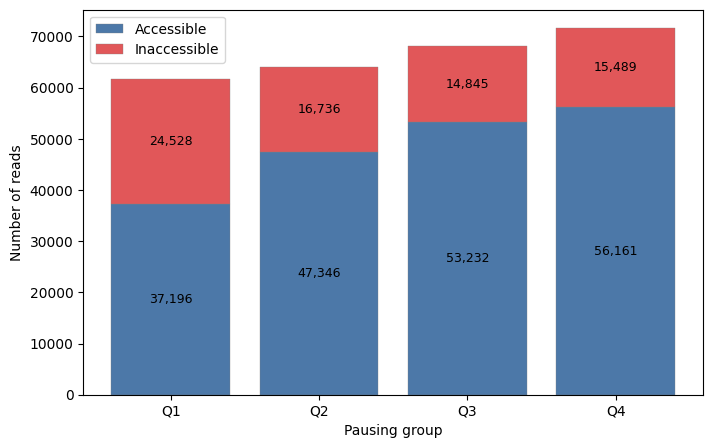

In [18]:
# plot the stacked bar plot
plt.figure(figsize=(8, 5))

bottoms = np.zeros(len(quartiles))

for acc in ["Accessible", "Inaccessible"]:
    subset = (
        accessibility_summary[accessibility_summary["accessibility"] == acc]
        .set_index("pi_quartile")
        .reindex(quartiles)
        .reset_index()
    )

    bars = plt.bar(
        subset["pi_quartile"],
        subset["n_reads"],
        bottom=bottoms,
        label=acc,
        color={"Accessible": "#4C78A8", "Inaccessible": "#E15759"}[acc],
        edgecolor="gray",
        linewidth=0.25,
    )

    # Add numbers inside each stacked bar segment
    for i, row in subset.iterrows():
        height = row["n_reads"]
        y_position = bottoms[i] + height / 2

        plt.text(
            x=i,
            y=y_position,
            s=f"{int(height):,}",
            ha="center",
            va="center",
            fontsize=9,
        )

    bottoms += subset["n_reads"].values

plt.xlabel("Pausing group")
plt.ylabel("Number of reads")
plt.legend()
plt.show()

# Does this fiber lack a nucleosome sized footprint directly at the TSS?
- adapted from Tullius et al. 2025, *Nature Genetics* 57: 1234-1245, "Chromatin fiber architecture and promoter-proximal pausing of RNA polymerase II"

the output table is saved at '/project/spott/cshan/fiber-seq/results/PolII/accessibility_and_promoter_pausing/ndr_accessibility_31samples_aw100_ndr20_minsize80.parquet'

In [ ]:
import re as _re

# Parameters (mirror Tullius et al. Fig 1 NDR criterion)
NDR_HALF        = 20                   # ±20 bp window around TSS (Tullius: positions -20 to +20)
NDR_FP_TYPE     = "nucleosome_140-160" # footprint class representing nucleosome-sized protections
NDR_MIN_FP_SIZE = 80                   # minimum footprint size counted as nucleosome 

_NDR_FP_BED_ROOT = Path("/project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds")

NDR_ACCESS_CACHE = Path(
    "/project/spott/cshan/fiber-seq/results/PolII/accessibility_and_promoter_pausing/"
    f"ndr_accessibility_31samples_aw{TSS_SPAN_HALF}_ndr{NDR_HALF}_minsize{NDR_MIN_FP_SIZE}.parquet"
)
force_ndr = False

# define read_core extractor here; identical logic to _read_core in the footprint-count cell below
_ndr_read_core_re = _re.compile(r"^.*?(m\d+_\d+_\d+_s\d+/.+)$")
def _ndr_read_core(s):
    m = _ndr_read_core_re.match(str(s))
    return m.group(1) if m else str(s)


def nucleosome_blocked_reads(tss_pairs, fp_bed_root=_NDR_FP_BED_ROOT,
                              fp_type=NDR_FP_TYPE, ndr_half=NDR_HALF,
                              min_fp_size=NDR_MIN_FP_SIZE):
    """Return DataFrame of (gene_name, chromosome, tss_coordinate, read_core)
    for fibers carrying a nucleosome-sized footprint (midpoint within +/-ndr_half bp,
    size >= min_fp_size bp) at the TSS.  These fibers are NOT NDR-accessible.
    Scans the pooled per-chromosome BED once for all selected TSS.
    """
    rows = []
    for row in tss_pairs.itertuples(index=False):
        chrom    = str(row.chromosome)
        tss      = int(row.tss_coordinate)
        bed_path = fp_bed_root / fp_type / f"{chrom}_footprints.bed.gz"
        if not bed_path.exists():
            continue
        tbx = pysam.TabixFile(str(bed_path))
        try:
            if chrom not in tbx.contigs:
                continue
            try:
                for rec in tbx.fetch(chrom, max(0, tss - ndr_half), tss + ndr_half + 1):
                    fields  = rec.split("\t")
                    fp_mid  = float(fields[5])
                    fp_size = int(fields[2]) - int(fields[1])
                    if abs(fp_mid - tss) <= ndr_half and fp_size >= min_fp_size:
                        rows.append((row.gene_name, chrom, tss, fields[3]))
            except ValueError:
                continue
        finally:
            tbx.close()
    return (pd.DataFrame(rows,
                         columns=["gene_name", "chromosome", "tss_coordinate", "read_core"])
              .drop_duplicates()
              .reset_index(drop=True))


if NDR_ACCESS_CACHE.exists() and not force_ndr:
    ndr_access_all_samples = pd.read_parquet(NDR_ACCESS_CACHE)
    print(f"Loaded cached results: {NDR_ACCESS_CACHE}")
else:
    # Scan pooled footprint BEDs once; merge with per-sample spanning reads below.
    print(f"Scanning {NDR_FP_TYPE} BEDs for nucleosomes within +-{NDR_HALF} bp of TSS ...")
    blocked_df = nucleosome_blocked_reads(tss_with_quartile)
    blocked_df["has_nuc"] = True
    print(f"  Unique read_cores with nucleosome at TSS: {blocked_df['read_core'].nunique():,}")

    meta = pd.read_csv(METATABLE_CSV)
    print(f"\nProcessing {len(meta)} samples ...")
    per_sample = []
    for _, sample_row in meta.iterrows():
        sn = sample_row["sample_name"]
        if not os.path.exists(sample_row["bam_file"]):
            print(f"  [skip] {sn}: missing BAM")
            continue
        sp_df = spanning_reads_for_sample(sample_row["bam_file"], tss_with_quartile, sn)
        if sp_df.empty:
            print(f"  [empty] {sn}: no spanning reads")
            continue
        sp_df["read_core"] = sp_df["read_id"].astype(str).map(_ndr_read_core)
        sp_df = sp_df.merge(
            blocked_df,
            on=["gene_name", "chromosome", "tss_coordinate", "read_core"],
            how="left",
        )
        sp_df["tss_accessible_ndr"] = ~sp_df["has_nuc"].fillna(False).astype(bool)
        sp_df = sp_df.drop(columns=["has_nuc", "read_core"])
        per_sample.append(sp_df)
        print(f"  {sn}: spanning={len(sp_df):,}  NDR-accessible={int(sp_df['tss_accessible_ndr'].sum()):,}")

    ndr_access_all_samples = pd.concat(per_sample, ignore_index=True)
    NDR_ACCESS_CACHE.parent.mkdir(parents=True, exist_ok=True)
    ndr_access_all_samples.to_parquet(NDR_ACCESS_CACHE, index=False)
    print(f"\nWrote {NDR_ACCESS_CACHE} ({len(ndr_access_all_samples):,} rows)")

# Pooled summary across all 31 samples by PI quartile
ndr_summary_all = (
    ndr_access_all_samples.groupby(["pi_quartile", "tss_accessible_ndr"], observed=True)
                          .agg(n_reads=("read_id", "nunique"))
                          .reset_index()
)
print("\nNDR accessibility pooled across 31 samples (PI quartiles):")
print(ndr_summary_all.to_string(index=False))

In [22]:
# inspect the table

nrd_summary = pd.read_parquet("/project/spott/cshan/fiber-seq/results/PolII/accessibility_and_promoter_pausing/ndr_accessibility_31samples_aw100_ndr20_minsize80.parquet")
nrd_summary.head(10)

,sample_name,gene_name,chromosome,tss_coordinate,pi_quartile,read_id,tss_accessible_ndr
0,AL6_bc2162_19093,RNF207,chr1,6206118,Q3,AL6_bc2162_19093-m84241_241120_172940_s3/24805...,True
1,AL6_bc2162_19093,RNF207,chr1,6206118,Q3,AL6_bc2162_19093-m84241_250514_222554_s2/50927...,True
2,AL6_bc2162_19093,ERRFI1,chr1,8026308,Q3,AL6_bc2162_19093-m84241_250910_205027_s2/21004...,True
3,AL6_bc2162_19093,ERRFI1,chr1,8026308,Q3,AL6_bc2162_19093-m84241_250514_222554_s2/18199...,True
4,AL6_bc2162_19093,ERRFI1,chr1,8026308,Q3,AL6_bc2162_19093-m84241_250514_222554_s2/19202...,True
5,AL6_bc2162_19093,ERRFI1,chr1,8026308,Q3,AL6_bc2162_19093-m84241_250910_205027_s2/11538...,True
6,AL6_bc2162_19093,ERRFI1,chr1,8026308,Q3,AL6_bc2162_19093-m84241_250514_222554_s2/15040...,True
7,AL6_bc2162_19093,ERRFI1,chr1,8026308,Q3,AL6_bc2162_19093-m84241_250910_205027_s2/96605...,True
8,AL6_bc2162_19093,ERRFI1,chr1,8026308,Q3,AL6_bc2162_19093-m84241_241120_172940_s3/23396...,True
9,AL6_bc2162_19093,ERRFI1,chr1,8026308,Q3,AL6_bc2162_19093-m84241_250910_184736_s1/23927...,True


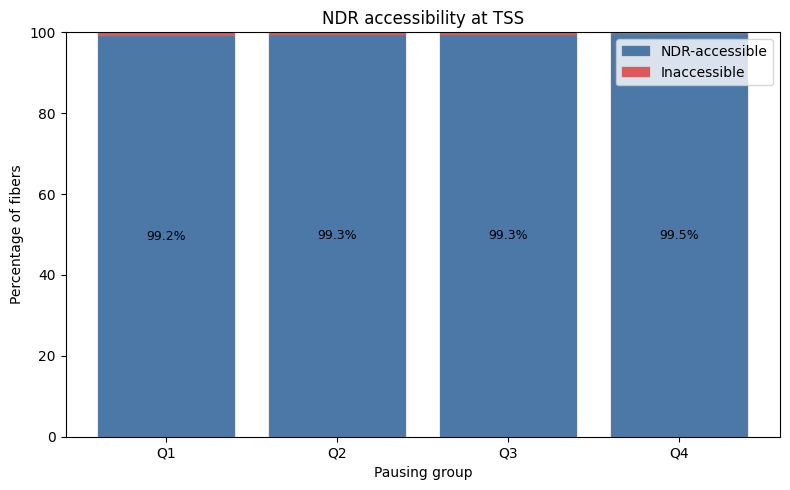

In [28]:
# NDR accessibility bar plot by PI quartile (percentage)
ndr_bar_summary = (
    nrd_summary.groupby(["pi_quartile", "tss_accessible_ndr"], observed=True)
               .agg(n_reads=("read_id", "nunique"))
               .reset_index()
)

ndr_bar_summary["accessibility"] = np.where(
    ndr_bar_summary["tss_accessible_ndr"],
    "NDR-accessible",
    "Inaccessible"
)

# Convert counts to percentages within each pausing group
ndr_bar_summary["percent"] = (
    ndr_bar_summary["n_reads"] /
    ndr_bar_summary.groupby("pi_quartile")["n_reads"].transform("sum")
    * 100
)

plt.figure(figsize=(8, 5))

bottoms = np.zeros(len(quartiles))

for acc, color in [("NDR-accessible", "#4C78A8"),
                   ("Inaccessible", "#E15759")]:
    subset = (
        ndr_bar_summary[ndr_bar_summary["accessibility"] == acc]
        .set_index("pi_quartile")
        .reindex(quartiles)
        .fillna(0)
        .reset_index()
    )

    plt.bar(
        subset["pi_quartile"],
        subset["percent"],
        bottom=bottoms,
        label=acc,
        color=color,
        edgecolor="gray",
        linewidth=0.25,
    )

    # Percentage labels
    for i, row in subset.iterrows():
        if row["percent"] > 3:  # don't label tiny slices
            plt.text(
                x=i,
                y=bottoms[i] + row["percent"] / 2,
                s=f"{row['percent']:.1f}%",
                ha="center",
                va="center",
                fontsize=9,
            )

    bottoms += subset["percent"].values

plt.xlabel("Pausing group")
plt.ylabel("Percentage of fibers")
plt.title("NDR accessibility at TSS")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

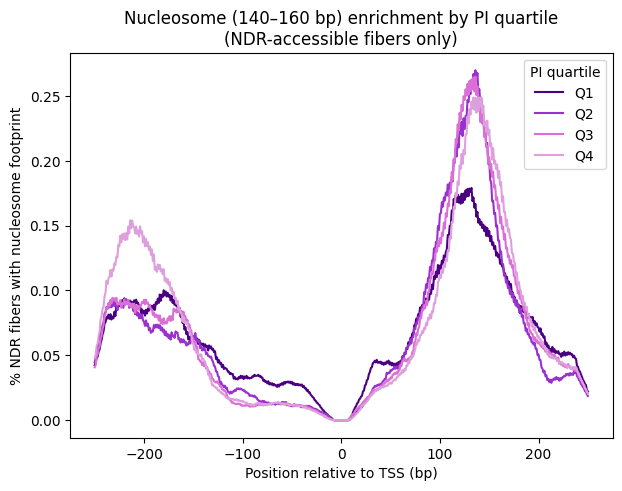

In [25]:
# Nucleosome enrichment by PI quartile for NDR-accessible fibers
# Analog of Tullius Cell 29: PPP enrichment for NDR reads by PI group.
# For each NDR-accessible (fiber, TSS), record the position of every
# nucleosome_140-160 footprint relative to TSS; divide by total NDR
# (fiber, TSS) pairs in each quartile to get fraction, then smooth.

ENRICH_FP_TYPE = "nucleosome_140-160"
ENRICH_WINDOW  = 250   # ±250 bp (Tullius: s=-250, e=250)
SMOOTH         = 25    # bp (Tullius: smooth=25)

# gene -> strand from selected_acc
gene_strand = (
    selected_acc[["gene_name", "tss_strand"]]
    .dropna(subset=["tss_strand"])
    .drop_duplicates(subset="gene_name")
    .set_index("gene_name")["tss_strand"]
    .to_dict()
)

# NDR-accessible rows with read_core stripped of sample prefix
ndr_acc_fibers = nrd_summary[nrd_summary["tss_accessible_ndr"]].copy()
ndr_acc_fibers["read_core"] = ndr_acc_fibers["read_id"].astype(str).map(_ndr_read_core)

# (gene, tss) -> {quartile -> set of accessible read_cores}
from collections import defaultdict
tss_to_acc = defaultdict(lambda: defaultdict(set))
for row in ndr_acc_fibers.itertuples(index=False):
    tss_to_acc[(row.gene_name, int(row.tss_coordinate))][row.pi_quartile].add(row.read_core)

# denominator: unique (fiber, TSS) pairs per quartile
total_ndr = (
    ndr_acc_fibers.drop_duplicates(subset=["read_core", "gene_name", "tss_coordinate"])
                  .groupby("pi_quartile")
                  .size()
                  .to_dict()
)

# Scan nucleosome BED for each selected TSS; collect (quartile, rel_pos) hits
_enrich_bed_root = Path(
    "/project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds"
)
unique_tss_ndr = (
    ndr_acc_fibers[["gene_name", "chromosome", "tss_coordinate"]]
    .drop_duplicates()
    .reset_index(drop=True)
)
pos_rows = []
for row in unique_tss_ndr.itertuples(index=False):
    gene   = row.gene_name
    chrom  = str(row.chromosome)
    tss    = int(row.tss_coordinate)
    strand = gene_strand.get(gene, "+")
    acc_by_q = tss_to_acc.get((gene, tss), {})
    if not acc_by_q:
        continue
    bed_path = _enrich_bed_root / ENRICH_FP_TYPE / f"{chrom}_footprints.bed.gz"
    if not bed_path.exists():
        continue
    tbx = pysam.TabixFile(str(bed_path))
    try:
        if chrom not in tbx.contigs:
            continue
        try:
            for rec in tbx.fetch(chrom, max(0, tss - ENRICH_WINDOW), tss + ENRICH_WINDOW + 1):
                fields = rec.split("\t")
                fp_mid = float(fields[5])
                rc     = fields[3]
                rel    = (fp_mid - tss) if strand == "+" else (tss - fp_mid)
                if abs(rel) > ENRICH_WINDOW:
                    continue
                for q, cores in acc_by_q.items():
                    if rc in cores:
                        pos_rows.append((q, int(round(rel))))
        except ValueError:
            continue
    finally:
        tbx.close()

pos_df = pd.DataFrame(pos_rows, columns=["pi_quartile", "rel_pos"])

# Fraction of NDR fibers with nucleosome at each position, smoothed
positions = np.arange(-ENRICH_WINDOW, ENRICH_WINDOW + 1)
q_colors  = {"Q1": "indigo", "Q2": "darkorchid", "Q3": "orchid", "Q4": "plum"}

fig, ax = plt.subplots(figsize=(7, 5))
for q in quartiles:
    n_tot  = total_ndr.get(q, 1)
    counts = pos_df[pos_df["pi_quartile"] == q]["rel_pos"].value_counts()
    y = np.array([counts.get(p, 0) for p in positions], dtype=float) / n_tot
    box = np.ones(SMOOTH) / SMOOTH
    y_sm = np.convolve(y, box, mode="same")
    ax.plot(positions, y_sm * 100, color=q_colors[q], label=q)

ax.set_xlabel("Position relative to TSS (bp)")
ax.set_ylabel("% NDR fibers with nucleosome footprint")
ax.set_title("Nucleosome (140–160 bp) enrichment by PI quartile\n(NDR-accessible fibers only)")
ax.legend(title="PI quartile")
plt.show()


# Filter pausing genes by expression

1. The results above was unexpected because we would expect the most paused genes to have the lowest nucloeosme counts. Sepcifically, we would expect the Q4 (high PI) genes to have the lowest number of nucleosome footprints. According to Tullius et al. 2025, chromatin fibers containing a promoter-proximal paused Pol II show disrupted nucleosome positioning, in some cases, the +1 nucleosome is completely absent. **This indicates pausing is associated with nucleosome depletion and destabilization of the downstream nucleosome positioning**

2. Highly paused genes haver lower expression levels compared to lowly paused genes
    - promoter accessibility: genes wtih low PI tend to have more fiber with accessible promoters to facilitate active transcription
    - transcription inhibition: while lowly paused genes allow for a more open and continuous progression of RNA polymerase, highly paused genes maintain a unique, disrupted downstream nucleosome positioning that acts as a state of transcription inhibition or rate limiting control


To account for this, I added an expression level filter to drop genes with very low expression levels as defined by the bottom quarter of genes with the lowest Pol II gene body signal




In [16]:
from pathlib import Path

TSS_SPAN_HALF = 100
NDR_HALF = 20
NDR_MIN_FP_SIZE = 80
NDR_FP_TYPE = "nucleosome_140-160"

In [17]:
# --- 1. Reload PI table  ---
pi_path = (
    "/project/spott/cshan/fiber-seq/results/PolII/annotations/"
    "pausing_index_principal_with_CAGE_TSS_all_genes.tsv"
)
pi_tbl = pd.read_csv(pi_path, sep="\t")
pi_tbl["cage_tss"] = pd.to_numeric(pi_tbl["cage_tss"], errors="coerce")
pi_tbl = (
    pi_tbl.dropna(subset=["cage_tss"])
          .sort_values("PI", ascending=False)
          .drop_duplicates(subset="gene_name")
          .reset_index(drop=True)
)

# --- 2. Expression filter ---
# GeneBody is normalized Pol II ChIP-seq signal (~1e-7 to ~1e-2).
# Threshold is the 25th percentile; override with a fixed value if needed.
log_gb = np.log10(pi_tbl.loc[pi_tbl["GeneBody"] > 0, "GeneBody"])
print("log10(GeneBody) distribution:")
for q in [0, 10, 25, 50, 75, 90, 100]:
    print(f"  {q:3d}th pct: {log_gb.quantile(q/100):.3f}  "
          f"(GeneBody = {10**log_gb.quantile(q/100):.2e})")
print()

EXPR_THRESHOLD = float(log_gb.quantile(0.25))
print(f"EXPR_THRESHOLD (25th pct): log10(GeneBody) > {EXPR_THRESHOLD:.3f}  "
      f"(GeneBody > {10**EXPR_THRESHOLD:.2e})")

pi_tbl_expr = (
    pi_tbl[
        (pi_tbl["GeneBody"] > 0)
        & (np.log10(pi_tbl["GeneBody"]) > EXPR_THRESHOLD)
    ]
    .dropna(subset=["PI"])
    .copy()
)
print(f"Genes passing filter: {len(pi_tbl_expr):,} / {len(pi_tbl):,}  "
      f"(removed {len(pi_tbl) - len(pi_tbl_expr):,})")

# --- 3. Quartile assignment (all genes per quartile) ---
pi_tbl_expr["pi_quartile"] = pd.qcut(
    pi_tbl_expr["PI"], 4, labels=["Q1", "Q2", "Q3", "Q4"]
)
selected_expr = (
    pi_tbl_expr.sort_values("PI", ascending=False)
               .reset_index(drop=True)
)
print("\nExpression-filtered selection per quartile:")
print(
    selected_expr.groupby("pi_quartile", observed=True)["PI"]
                 .agg(n="count", min_PI="min", max_PI="max")
                 .reset_index()
                 .to_string(index=False)
)

log10(GeneBody) distribution:
    0th pct: -5.028  (GeneBody = 9.37e-06)
   10th pct: -3.749  (GeneBody = 1.78e-04)
   25th pct: -3.608  (GeneBody = 2.47e-04)
   50th pct: -3.440  (GeneBody = 3.63e-04)
   75th pct: -3.255  (GeneBody = 5.55e-04)
   90th pct: -3.067  (GeneBody = 8.58e-04)
  100th pct: -2.067  (GeneBody = 8.58e-03)

EXPR_THRESHOLD (25th pct): log10(GeneBody) > -3.608  (GeneBody > 2.47e-04)
Genes passing filter: 4,889 / 6,519  (removed 1,630)

Expression-filtered selection per quartile:
pi_quartile    n   min_PI    max_PI
         Q1 1223 0.045216  2.105514
         Q2 1222 2.110377  4.317284
         Q3 1222 4.322375  7.426372
         Q4 1222 7.427615 32.152240


In [18]:
# --- 4. TSS coordinate table for BAM + BED scanning ---
# Use cage_tss (all genes already CAGE-filtered above).
tss_with_quartile_expr = (
    selected_expr[["gene_name", "chrom", "cage_tss", "pi_quartile"]]
    .dropna(subset=["chrom", "cage_tss"])
    .rename(columns={"chrom": "chromosome", "cage_tss": "tss_coordinate"})
    .astype({"tss_coordinate": int, "pi_quartile": str})
    .drop_duplicates()
    .reset_index(drop=True)
)
print(f"\nTSS list: {len(tss_with_quartile_expr):,} entries  "
      f"({tss_with_quartile_expr['gene_name'].nunique():,} genes)")



TSS list: 4,889 entries  (4,889 genes)


In [19]:
# --- 5. Recompute NDR accessibility across 31 samples from expression-filtered PI table ---
import re as _re

METATABLE_CSV_EXPR = "/project/spott/1_Shared_projects/LCL_Fiber_seq/Data/LCL_sample_metatable_merged_samples_31samples.csv"
NDR_FP_BED_ROOT_EXPR = Path("/project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds")

_ndr_read_core_expr_re = _re.compile(r"^.*?(m\d+_\d+_\d+_s\d+/.+)$")
def _ndr_read_core_expr(s):
    m = _ndr_read_core_expr_re.match(str(s))
    return m.group(1) if m else str(s)


def nucleosome_blocked_reads_expr(tss_pairs, fp_bed_root=NDR_FP_BED_ROOT_EXPR,
                                  fp_type=NDR_FP_TYPE, ndr_half=NDR_HALF,
                                  min_fp_size=NDR_MIN_FP_SIZE):
    """Return expression-filtered TSS/read pairs blocked by TSS-proximal nucleosomes."""
    rows = []
    for row in tss_pairs.itertuples(index=False):
        chrom = str(row.chromosome)
        tss = int(row.tss_coordinate)
        bed_path = fp_bed_root / fp_type / f"{chrom}_footprints.bed.gz"
        if not bed_path.exists():
            continue
        tbx = pysam.TabixFile(str(bed_path))
        try:
            if chrom not in tbx.contigs:
                continue
            try:
                for rec in tbx.fetch(chrom, max(0, tss - ndr_half), tss + ndr_half + 1):
                    fields = rec.split("\t")
                    fp_mid = float(fields[5])
                    fp_size = int(fields[2]) - int(fields[1])
                    if abs(fp_mid - tss) <= ndr_half and fp_size >= min_fp_size:
                        rows.append((row.gene_name, chrom, tss, fields[3]))
            except ValueError:
                continue
        finally:
            tbx.close()
    return (pd.DataFrame(
        rows,
        columns=["gene_name", "chromosome", "tss_coordinate", "read_core"],
    ).drop_duplicates().reset_index(drop=True))


def spanning_reads_for_sample_expr(bam_path, tss_pairs, sample_name,
                                   half_window=TSS_SPAN_HALF):
    """Reads in `bam_path` whose alignment fully spans TSS +/- half_window."""
    rows = []
    with pysam.AlignmentFile(bam_path, "rb") as bam:
        bam_chroms = set(bam.references)
        for row in tss_pairs.itertuples(index=False):
            chrom = str(row.chromosome)
            if chrom not in bam_chroms:
                continue
            tss = int(row.tss_coordinate)
            win_lo = tss - half_window
            win_hi_excl = tss + half_window + 1
            for aln in bam.fetch(chrom, win_lo, win_hi_excl):
                if (aln.is_unmapped or aln.is_secondary
                        or aln.is_supplementary or aln.is_duplicate):
                    continue
                if aln.reference_start <= win_lo and aln.reference_end >= win_hi_excl:
                    rows.append((
                        sample_name, row.gene_name, chrom, tss, row.pi_quartile,
                        f"{sample_name}-{aln.query_name}",
                    ))
    return pd.DataFrame(
        rows,
        columns=["sample_name", "gene_name", "chromosome", "tss_coordinate",
                 "pi_quartile", "read_id"],
    ).drop_duplicates().reset_index(drop=True)


print(f"Scanning {NDR_FP_TYPE} BEDs for nucleosomes within +-{NDR_HALF} bp of TSS ...")
blocked_df_expr = nucleosome_blocked_reads_expr(tss_with_quartile_expr)
blocked_df_expr["has_nuc"] = True
print(f"  Unique read_cores with nucleosome at TSS: "
      f"{blocked_df_expr['read_core'].nunique():,}")

meta = pd.read_csv(METATABLE_CSV_EXPR)
print(f"\nProcessing {len(meta)} samples ...")
per_sample_expr = []
for _, sample_row in meta.iterrows():
    sn = sample_row["sample_name"]
    if not os.path.exists(sample_row["bam_file"]):
        print(f"  [skip] {sn}: missing BAM")
        continue
    sp_df = spanning_reads_for_sample_expr(
        sample_row["bam_file"], tss_with_quartile_expr, sn
    )
    if sp_df.empty:
        print(f"  [empty] {sn}: no spanning reads")
        continue
    sp_df["read_core"] = sp_df["read_id"].astype(str).map(_ndr_read_core_expr)
    sp_df = sp_df.merge(
        blocked_df_expr,
        on=["gene_name", "chromosome", "tss_coordinate", "read_core"],
        how="left",
    )
    sp_df["tss_accessible_ndr"] = ~sp_df["has_nuc"].eq(True)
    sp_df = sp_df.drop(columns=["has_nuc", "read_core"])
    per_sample_expr.append(sp_df)
    print(f"  {sn}: spanning={len(sp_df):,}  "
          f"NDR-accessible={int(sp_df['tss_accessible_ndr'].sum()):,}")

if not per_sample_expr:
    raise RuntimeError("No spanning reads found for expression-filtered NDR accessibility")

ndr_expr = pd.concat(per_sample_expr, ignore_index=True)
print(f"\nRecomputed expression-filtered NDR accessibility ({len(ndr_expr):,} rows)")


Scanning nucleosome_140-160 BEDs for nucleosomes within +-20 bp of TSS ...
  Unique read_cores with nucleosome at TSS: 23,881

Processing 31 samples ...


[W::hts_idx_load3] The index file is older than the data file: /project/spott/1_Shared_projects/LCL_Fiber_seq/preprocess_final_merged_samples/AL6_bc2162_19093.5mC.6mA.aligned.phased.bam.bai


  AL6_bc2162_19093: spanning=33,865  NDR-accessible=33,628
  AL8_bc2170_19151: spanning=58,012  NDR-accessible=57,546
  AL10_bc2178_19130: spanning=92,894  NDR-accessible=92,002
  AL16_bc2114_18508: spanning=55,627  NDR-accessible=55,229


[W::hts_idx_load3] The index file is older than the data file: /project/spott/1_Shared_projects/LCL_Fiber_seq/preprocess_final_merged_samples/AL18_bc2130_18504.5mC.6mA.aligned.phased.bam.bai


  AL18_bc2130_18504: spanning=86,736  NDR-accessible=85,944


...

  AL61_bc2160_18498: spanning=73,117  NDR-accessible=72,342


[W::hts_idx_load3] The index file is older than the data file: /project/spott/1_Shared_projects/LCL_Fiber_seq/preprocess_final_merged_samples/AL62_bc2168_19140.5mC.6mA.aligned.phased.bam.bai


  AL62_bc2168_19140: spanning=69,904  NDR-accessible=69,181


[W::hts_idx_load3] The index file is older than the data file: /project/spott/1_Shared_projects/LCL_Fiber_seq/preprocess_final_merged_samples/AL29AL40AL53_bc2171bc2141bc2132_18916.5mC.6mA.aligned.phased.bam.bai


  AL29AL40AL53_bc2171bc2141bc2132_18916: spanning=211,881  NDR-accessible=210,090

Recomputed expression-filtered NDR accessibility (3,086,156 rows)


In [20]:
# Summary by PI quartile
ndr_expr_summary = (
    ndr_expr.groupby(["pi_quartile", "tss_accessible_ndr"], observed=True)
            .agg(n_reads=("read_id", "nunique"))
            .reset_index()
)
print("\nNDR accessibility pooled across 31 samples (expression-filtered):")
print(ndr_expr_summary.to_string(index=False))



NDR accessibility pooled across 31 samples (expression-filtered):
pi_quartile  tss_accessible_ndr  n_reads
         Q1               False     9063
         Q1                True   686533
         Q2               False     6282
         Q2                True   717994
         Q3               False     4268
         Q3                True   763940
         Q4               False     3892
         Q4                True   810793


In [21]:
from pathlib import Path

# Save the expression-filtered NDR accessibility results
NDR_EXPR_ACCESS_CACHE = Path(
    "/project/spott/cshan/fiber-seq/results/PolII/accessibility_and_promoter_pausing/"
    f"ndr_accessibility_expression_filtered_aw{TSS_SPAN_HALF}_"
    f"ndr{NDR_HALF}_minsize{NDR_MIN_FP_SIZE}.parquet"
)

NDR_EXPR_ACCESS_CACHE.parent.mkdir(parents=True, exist_ok=True)
ndr_expr.to_parquet(NDR_EXPR_ACCESS_CACHE, index=False)

print(f"\nWrote {NDR_EXPR_ACCESS_CACHE} ({len(ndr_expr):,} rows)")


Wrote /project/spott/cshan/fiber-seq/results/PolII/accessibility_and_promoter_pausing/ndr_accessibility_expression_filtered_aw100_ndr20_minsize80.parquet (3,086,156 rows)


Loaded cached results: /project/spott/cshan/fiber-seq/results/PolII/accessibility_and_promoter_pausing/ndr_accessibility_expression_filtered_aw100_ndr20_minsize80.parquet


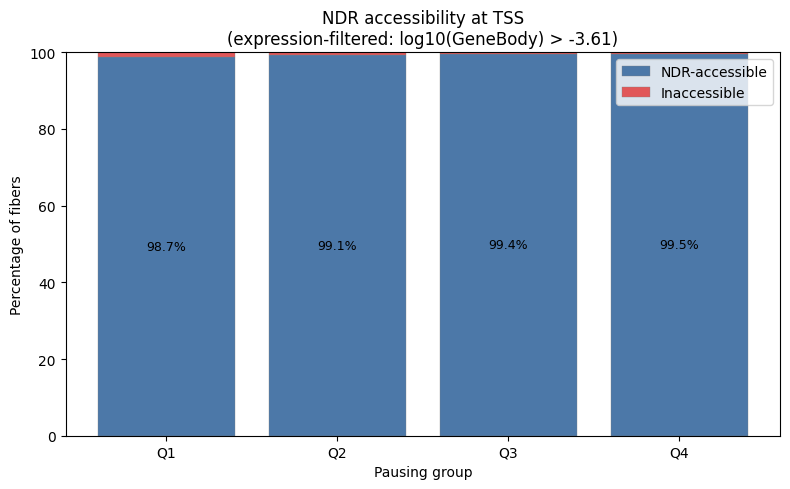

In [24]:
# NDR accessibility bar plot - expression-filtered genes

# read in the expression-filtered NDR accessibility results

EXPR_THRESHOLD = float(log_gb.quantile(0.25))

NDR_EXPR_ACCESS_CACHE = Path(
    "/project/spott/cshan/fiber-seq/results/PolII/accessibility_and_promoter_pausing/"
    f"ndr_accessibility_expression_filtered_aw{TSS_SPAN_HALF}_"
    f"ndr{NDR_HALF}_minsize{NDR_MIN_FP_SIZE}.parquet"
)

if NDR_EXPR_ACCESS_CACHE.exists():
    ndr_expr = pd.read_parquet(NDR_EXPR_ACCESS_CACHE)
    print(f"Loaded cached results: {NDR_EXPR_ACCESS_CACHE}")    

quartiles_expr = ["Q1", "Q2", "Q3", "Q4"]

ndr_bar_expr = (
    ndr_expr.groupby(["pi_quartile", "tss_accessible_ndr"], observed=True)
            .agg(n_reads=("read_id", "nunique"))
            .reset_index()
)
ndr_bar_expr["accessibility"] = np.where(
    ndr_bar_expr["tss_accessible_ndr"], "NDR-accessible", "Inaccessible"
)
ndr_bar_expr["percent"] = (
    ndr_bar_expr["n_reads"]
    / ndr_bar_expr.groupby("pi_quartile")["n_reads"].transform("sum")
    * 100
)

plt.figure(figsize=(8, 5))
bottoms = np.zeros(len(quartiles_expr))
for acc, color in [("NDR-accessible", "#4C78A8"), ("Inaccessible", "#E15759")]:
    subset = (
        ndr_bar_expr[ndr_bar_expr["accessibility"] == acc]
        .set_index("pi_quartile")
        .reindex(quartiles_expr)
        .fillna(0)
        .reset_index()
    )
    plt.bar(
        subset["pi_quartile"], subset["percent"],
        bottom=bottoms, label=acc, color=color,
        edgecolor="gray", linewidth=0.25,
    )
    for i, row in subset.iterrows():
        if row["percent"] > 3:
            plt.text(
                x=i, y=bottoms[i] + row["percent"] / 2,
                s=f"{row['percent']:.1f}%",
                ha="center", va="center", fontsize=9,
            )
    bottoms += subset["percent"].values

plt.xlabel("Pausing group")
plt.ylabel("Percentage of fibers")
plt.title(
    f"NDR accessibility at TSS\n"
    f"(expression-filtered: log10(GeneBody) > {EXPR_THRESHOLD:.2f})"
)
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()


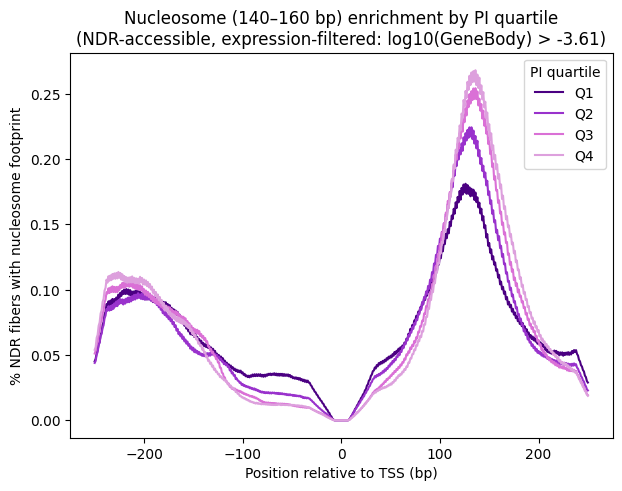

In [23]:
# Nucleosome enrichment by PI quartile — expression-filtered NDR-accessible fibers
from collections import defaultdict

quartiles_expr = ["Q1", "Q2", "Q3", "Q4"]
ENRICH_FP_TYPE_EXPR = NDR_FP_TYPE
ENRICH_WINDOW_EXPR = 250
SMOOTH_EXPR = 25
NDR_FP_BED_ROOT_EXPR = Path("/project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds")
positions_expr = np.arange(-ENRICH_WINDOW_EXPR, ENRICH_WINDOW_EXPR + 1)
q_colors_expr = {"Q1": "indigo", "Q2": "darkorchid", "Q3": "orchid", "Q4": "plum"}


# strand from pi_tbl_expr (covers all expression-filtered genes, not just original 400)
gene_strand_expr = (
    pi_tbl_expr[["gene_name", "strand"]]
    .drop_duplicates(subset="gene_name")
    .set_index("gene_name")["strand"]
    .to_dict()
)

ndr_acc_expr = ndr_expr[ndr_expr["tss_accessible_ndr"]].copy()
ndr_acc_expr["read_core"] = ndr_acc_expr["read_id"].astype(str).map(_ndr_read_core_expr)

tss_to_acc_expr = defaultdict(lambda: defaultdict(set))
for row in ndr_acc_expr.itertuples(index=False):
    tss_to_acc_expr[(row.gene_name, int(row.tss_coordinate))][row.pi_quartile].add(row.read_core)

total_ndr_expr = (
    ndr_acc_expr.drop_duplicates(subset=["read_core", "gene_name", "tss_coordinate"])
               .groupby("pi_quartile")
               .size()
               .to_dict()
)

unique_tss_expr = (
    ndr_acc_expr[["gene_name", "chromosome", "tss_coordinate"]]
    .drop_duplicates()
    .reset_index(drop=True)
)
pos_rows_expr = []
for row in unique_tss_expr.itertuples(index=False):
    gene   = row.gene_name
    chrom  = str(row.chromosome)
    tss    = int(row.tss_coordinate)
    strand = gene_strand_expr.get(gene, "+")
    acc_by_q = tss_to_acc_expr.get((gene, tss), {})
    if not acc_by_q:
        continue
    bed_path = NDR_FP_BED_ROOT_EXPR / ENRICH_FP_TYPE_EXPR / f"{chrom}_footprints.bed.gz"
    if not bed_path.exists():
        continue
    tbx = pysam.TabixFile(str(bed_path))
    try:
        if chrom not in tbx.contigs:
            continue
        try:
            for rec in tbx.fetch(chrom, max(0, tss - ENRICH_WINDOW_EXPR), tss + ENRICH_WINDOW_EXPR + 1):
                fields = rec.split("\t")
                fp_mid = float(fields[5])
                rc     = fields[3]
                rel    = (fp_mid - tss) if strand == "+" else (tss - fp_mid)
                if abs(rel) > ENRICH_WINDOW_EXPR:
                    continue
                for q, cores in acc_by_q.items():
                    if rc in cores:
                        pos_rows_expr.append((q, int(round(rel))))
        except ValueError:
            continue
    finally:
        tbx.close()

pos_df_expr = pd.DataFrame(pos_rows_expr, columns=["pi_quartile", "rel_pos"])

fig, ax = plt.subplots(figsize=(7, 5))
for q in quartiles_expr:
    n_tot  = total_ndr_expr.get(q, 1)
    counts = pos_df_expr[pos_df_expr["pi_quartile"] == q]["rel_pos"].value_counts()
    y = np.array([counts.get(p, 0) for p in positions_expr], dtype=float) / n_tot
    box = np.ones(SMOOTH_EXPR) / SMOOTH_EXPR
    y_sm = np.convolve(y, box, mode="same")
    ax.plot(positions_expr, y_sm * 100, color=q_colors_expr[q], label=q)

ax.set_xlabel("Position relative to TSS (bp)")
ax.set_ylabel("% NDR fibers with nucleosome footprint")
ax.set_title(
    "Nucleosome (140–160 bp) enrichment by PI quartile\n"
    f"(NDR-accessible, expression-filtered: log10(GeneBody) > {EXPR_THRESHOLD:.2f})"
)
ax.legend(title="PI quartile")
plt.show()


In [19]:
%%bash

less /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr1_footprints.bed.gz | head

chr1	10000	10018	m84241_250909_000942_s2/264508392/ccs	FIRE_nucleosome	10009.0
chr1	10000	10020	m84241_250908_220650_s1/250481348/ccs	FIRE_nucleosome	10010.0
chr1	10000	10024	m84241_250326_031141_s3/130221495/ccs	FIRE_nucleosome	10012.0
chr1	10000	10030	m84241_250514_222554_s2/266278306/ccs	FIRE_nucleosome	10015.0
chr1	10000	10044	m84241_250326_010847_s2/18220681/ccs	FIRE_nucleosome	10022.0
chr1	10000	10048	m84241_250906_015218_s2/106303285/ccs	FIRE_nucleosome	10024.0
chr1	10000	10050	m84241_250908_200356_s4/54790654/ccs	FIRE_nucleosome	10025.0
chr1	10000	10056	m84241_250326_010847_s2/156568420/ccs	FIRE_nucleosome	10028.0
chr1	10000	10056	m84241_250906_015218_s2/215484369/ccs	FIRE_nucleosome	10028.0
chr1	10000	10062	m84241_250905_234909_s1/164431819/ccs	FIRE_nucleosome	10031.0


#### for each selected read near a gene TSS, how many footprints occur on this read within this distance from the TSS?
- FIRE_nucleosome within ±250 bp, ±500 bp, ±1000 bp
- PIC within ±250 bp, ±500 bp, ±1000 bp
- PPP within ±250 bp, ±500 bp, ±1000 bp
- nucleosome_140-160 within ±250 bp, ±500 bp, ±1000 bp

In [ ]:
# Compute per-read footprint counts within TSS +/- distance for each
# (footprint_type, window) combination. Save one parquet per config to
# OUT_DIR and keep the per-config DataFrames in `fp_count_tables` for the
# downstream plotting / stats cells.
#
# Accessibility source: the FIRE-all-31-samples table (Method 2 batch),
# renamed so the existing function's `tss_accessible` branch picks it up.
# The footprint summary BEDs are pooled-31-sample, so a per-(sample, read)
# row from `fire_access_all_samples` looks up footprints from the right
# pool. Cross-sample read_core collisions are theoretically possible but
# vanishingly rare for PacBio CCS qnames (instrument+date+time+zmw).

import re
from pathlib import Path

#  Configuration
FP_BED_ROOT = Path("/project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds")
OUT_DIR     = Path("/project/spott/cshan/fiber-seq/results/PolII/accessibility_and_promoter_pausing")
OUT_DIR.mkdir(parents=True, exist_ok=True)

FP_TYPES    = ["FIRE_nucleosome", "PIC", "PPP", "nucleosome_140-160"]
WINDOWS     = [250, 500, 1000]   # half-widths in bp around each TSS
READ_FILTER = "accessible"       # "all": every spanning read in fire_access_all_samples
                                 # "accessible": only tss_accessible_fire == True

# Use the FIRE-all-31-samples accessibility table; rename so compute_fp_counts
# sees `tss_accessible` as expected.
access_df = fire_access_all_samples.rename(columns={"tss_accessible_fire": "tss_accessible"})

# compiles regular expression to extract the read core from a read_id string
## .*?: match any characters up to the first occurrence of "m\d+_\d+_\d+_s\d+/.+"
## m\d+_\d+_\d+_s\d+/.+: match the read core pattern (e.g. "m123_45_67_s89/0")

_read_core_re = re.compile(r"^.*?(m\d+_\d+_\d+_s\d+/.+)$")
def _read_core(s):
    m = _read_core_re.match(str(s))
    # m.group(1) is the read core if the pattern matches; otherwise return the original string
    return m.group(1) if m else str(s)


def compute_fp_counts(selected_acc, fp_type, window, read_filter="accessible"):
    """
    Per-read footprint counts within TSS +/- window for one footprint type.

    read_filter:
      "all"        - every row in selected_acc.
      "accessible" - only reads with tss_accessible == True.
    Reads with no matching footprint records get n_footprints = 0.
    """
    fp_bed_dir = FP_BED_ROOT / fp_type

    # Keep every unique TSS per gene; merge below pairs each read with its own TSS
    # for genes with multiple TSS, we keep them all here and the read-TSS merge below will create multiple rows for reads that overlap multiple TSS
    tss_per_gene = (
        selected_acc[["gene_name", "chromosome", "tss_coordinate"]]
        .dropna(subset=["chromosome", "tss_coordinate"])
        .drop_duplicates(subset=["gene_name", "chromosome", "tss_coordinate"])
        .reset_index(drop=True)
    )

    #####################
    # For each TSS in tss_per_gene, count the number of footprints from the bed files of each read_core that overlap TSS +/- window
    #####################
    fp_rows = []
    for _, row in tss_per_gene.iterrows():
        gene  = row["gene_name"]
        chrom = str(row["chromosome"])
        tss   = int(row["tss_coordinate"])
        bed_path = fp_bed_dir / f"{chrom}_footprints.bed.gz"
        # if the bed file for this chromosome doesn't exist, skip it (e.g. no footprints observed on this chrom)
        if not bed_path.exists():
            continue
        # count the number of footprints of each read_core that overlap TSS +/- window
        ## every read start with count = 0, and we increment the count for the read_core of each overlapping footprint
        counts = defaultdict(int)
        tbx = pysam.TabixFile(str(bed_path))
        try:
            if chrom not in tbx.contigs:
                continue
            # fetch returns an iterator over the lines in the bed file that overlap the region [tss - window, tss + window) on the given chrom
            start = max(0, tss - window)
            end = tss + window
            try:
                # each line in the bed file has fields: chrom, start, end, read_id, class, midpoint
                for rec in tbx.fetch(chrom, start, end):
                    fields = rec.split("\t")
                    fp_mid = float(fields[5])
                    # check if the footprint midpoint is within TSS +/- window; if so, increment the count for the read_core of this footprint
                    if (tss - window) <= fp_mid <= (tss + window):
                        counts[fields[3]] += 1
            except ValueError:
                continue
        finally:
            tbx.close()
        # loops through the counts dictionary and appends a row for each read_core with its footprint count for this TSS
        for rc, n in counts.items():
            fp_rows.append({"gene_name": gene, "tss_coordinate": tss, "read_core": rc, "n_footprints": n})

    fp_counts = pd.DataFrame(fp_rows, columns=["gene_name", "tss_coordinate", "read_core", "n_footprints"])

    if read_filter == "all":
        reads = selected_acc.copy()
    elif read_filter == "accessible":
        reads = selected_acc[selected_acc["tss_accessible"].astype(bool)].copy()
    else:
        raise ValueError(f"unknown read_filter: {read_filter!r}")
    reads["read_core"] = reads["read_id"].astype(str).map(_read_core)

    # a footprint count is attached to each read-TSS pair based on the read_core; reads with no matching footprint records get n_footprints = 0
    ## attached when all three match: gene_name, tss_coordinate, and read_core; if no match, n_footprints will be NaN and we fillna(0) below
    out = reads.merge(fp_counts, on=["gene_name", "tss_coordinate", "read_core"], how="left")
    out["n_footprints"] = out["n_footprints"].fillna(0).astype(int)
    return out


 # ── Run all combinations ─────────────────────────────────────────────────
fp_count_tables = {}
for fp_type in FP_TYPES:
    for window in WINDOWS:
        df = compute_fp_counts(access_df, fp_type, window, READ_FILTER)
        out_path = OUT_DIR / f"{fp_type}_w{window}_{READ_FILTER}_fire_all.parquet"
        df.to_parquet(out_path, index=False)
        fp_count_tables[(fp_type, window)] = df

        summary = (
            df.groupby("pi_quartile", observed=True)
              .agg(n_reads=("read_id", "nunique"),
                   mean_fp=("n_footprints", "mean"),
                   median_fp=("n_footprints", "median"))
              .round(2).reset_index()
        )
        print(f"=== {fp_type}  +/- {window} bp  rows={len(df):,}  -> {out_path.name}")
        print(summary.to_string(index=False))
        print()

print(f"Wrote {len(fp_count_tables)} tables to {OUT_DIR}")

In [15]:
# Quick duplicate-TSS sanity check on selected_acc
tss_raw = (
    selected_acc[["gene_name", "chromosome", "tss_coordinate", "read_id"]]
    .dropna(subset=["chromosome", "tss_coordinate", "read_id"])
)

dup_mask = tss_raw.duplicated(
    subset=["gene_name", "chromosome", "tss_coordinate"], keep=False
)
print(f"Total rows: {len(tss_raw):,}")
print(f"Duplicate rows by gene+chrom+tss: {dup_mask.sum():,}")

multi_tss = (
    tss_raw.groupby("gene_name")["tss_coordinate"].nunique()
    .reset_index(name="n_tss").query("n_tss > 1")
)
print(f"Genes with >1 distinct TSS coordinate in selected_acc: {len(multi_tss)}")

Total rows: 1,543,453
Duplicate rows by gene+chrom+tss: 1,543,453
Genes with >1 distinct TSS coordinate in selected_acc: 0


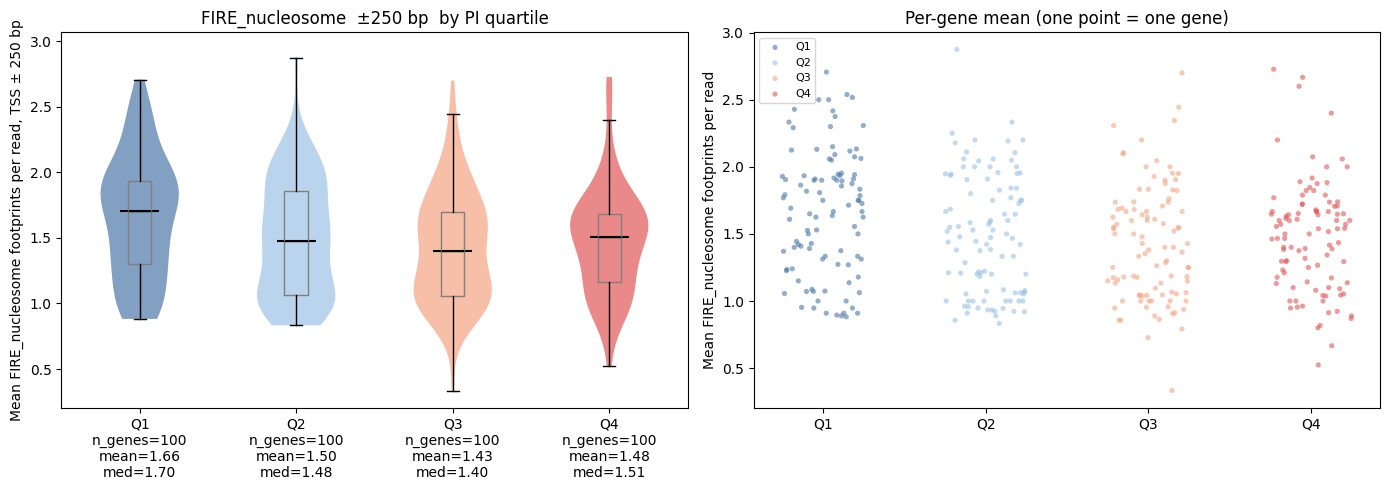

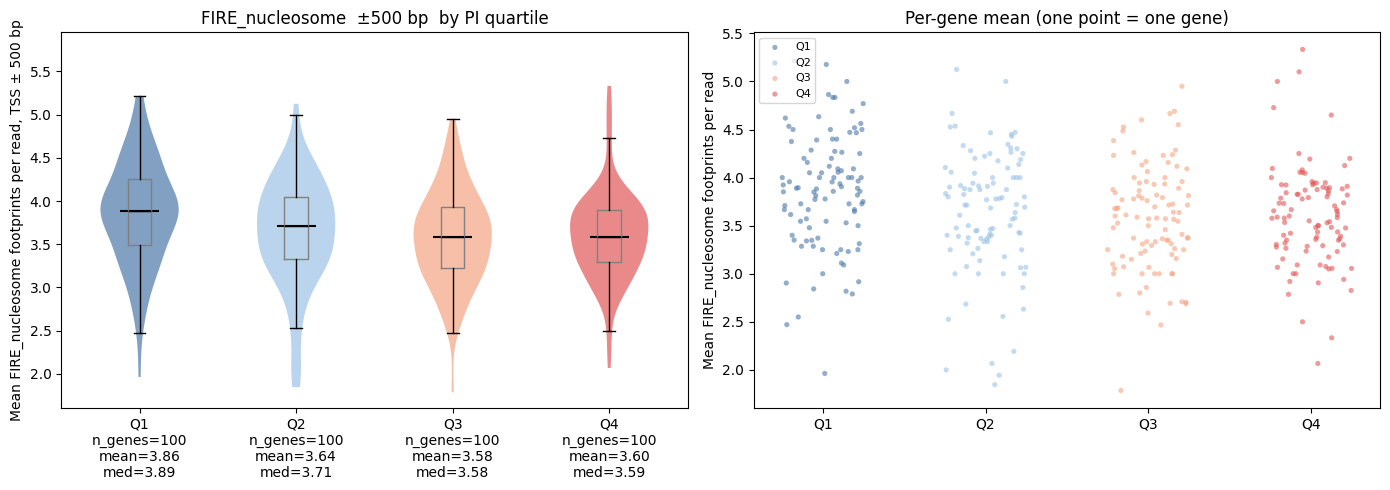

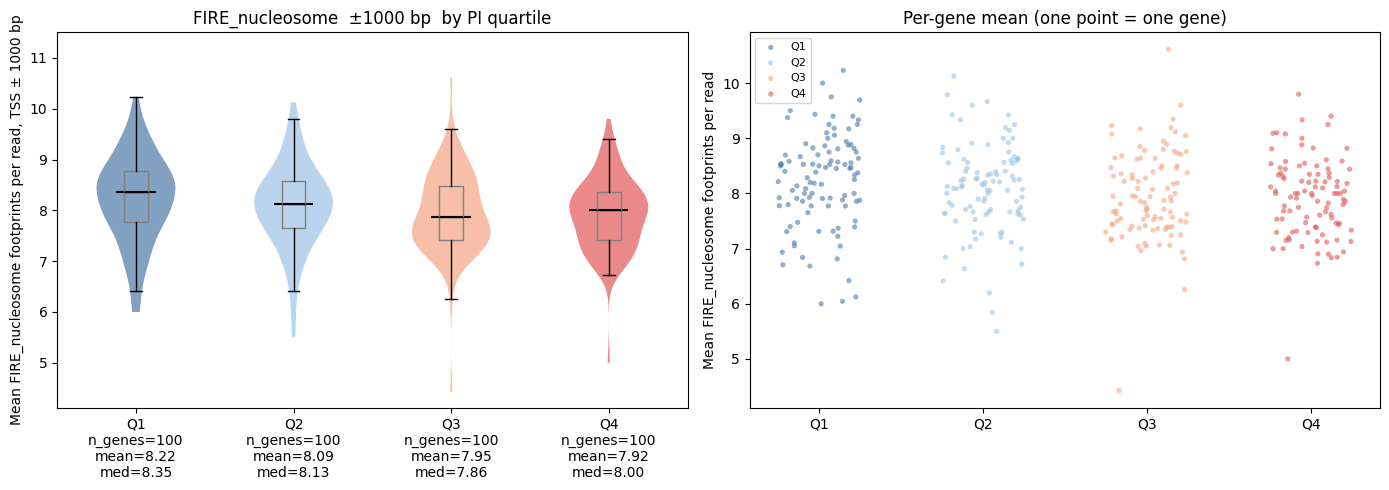

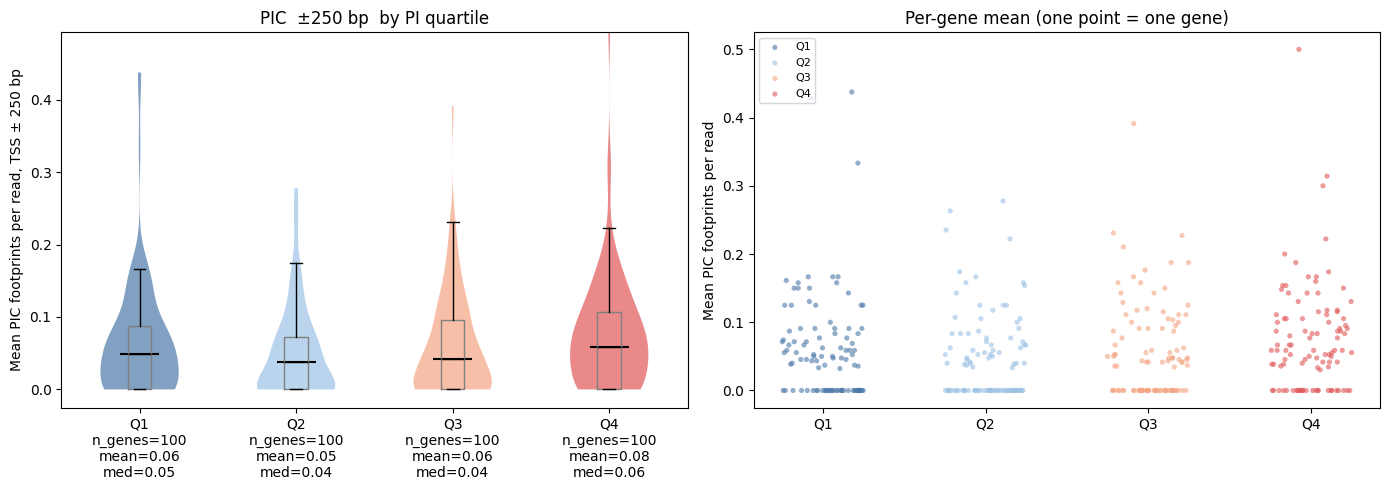

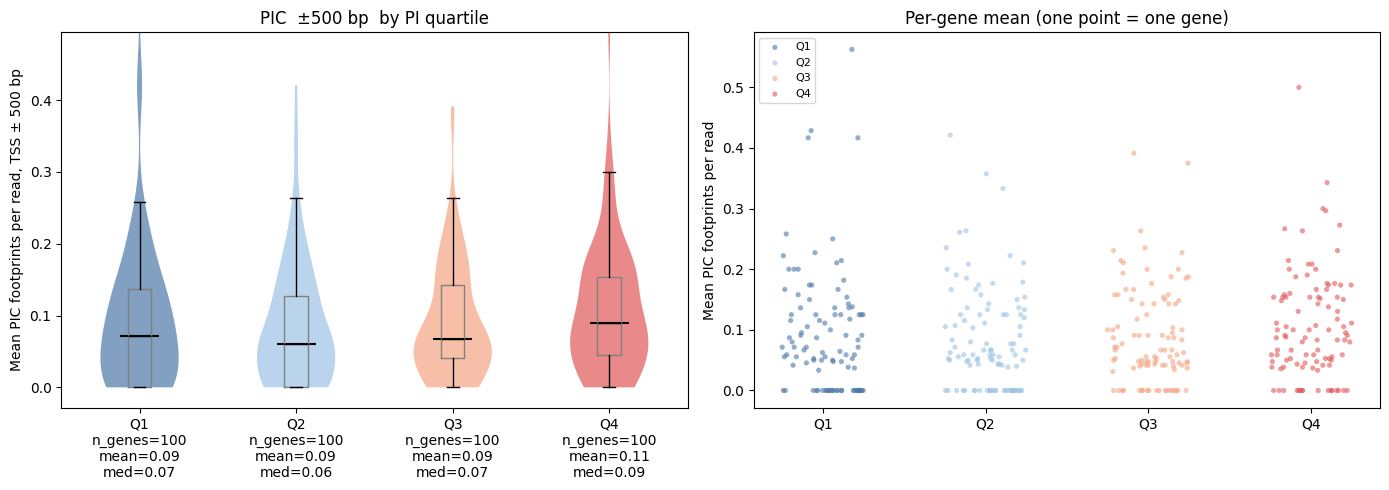

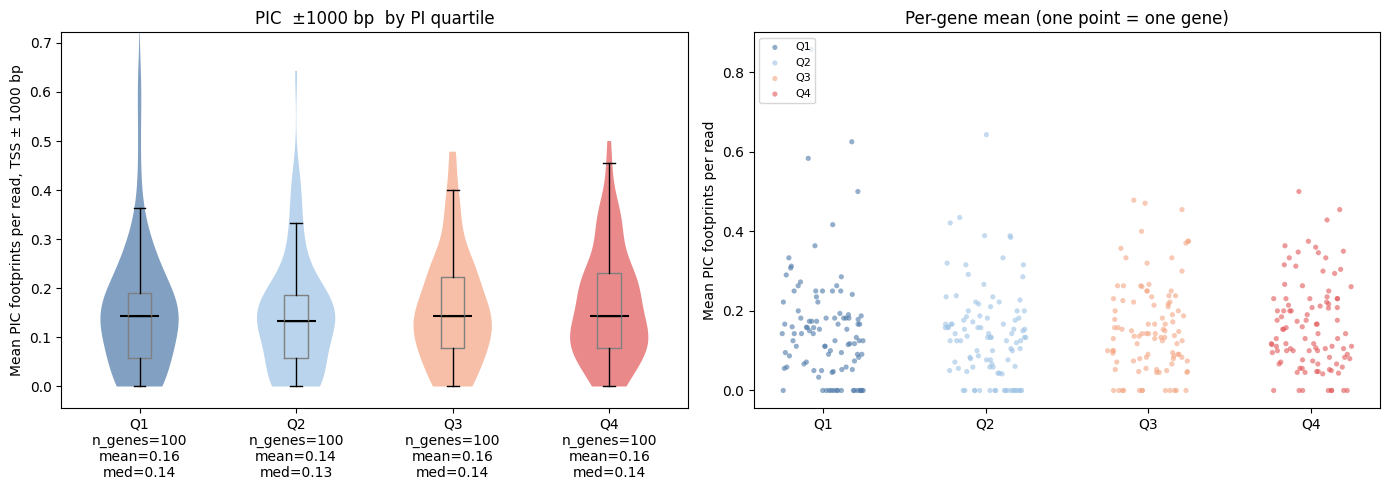

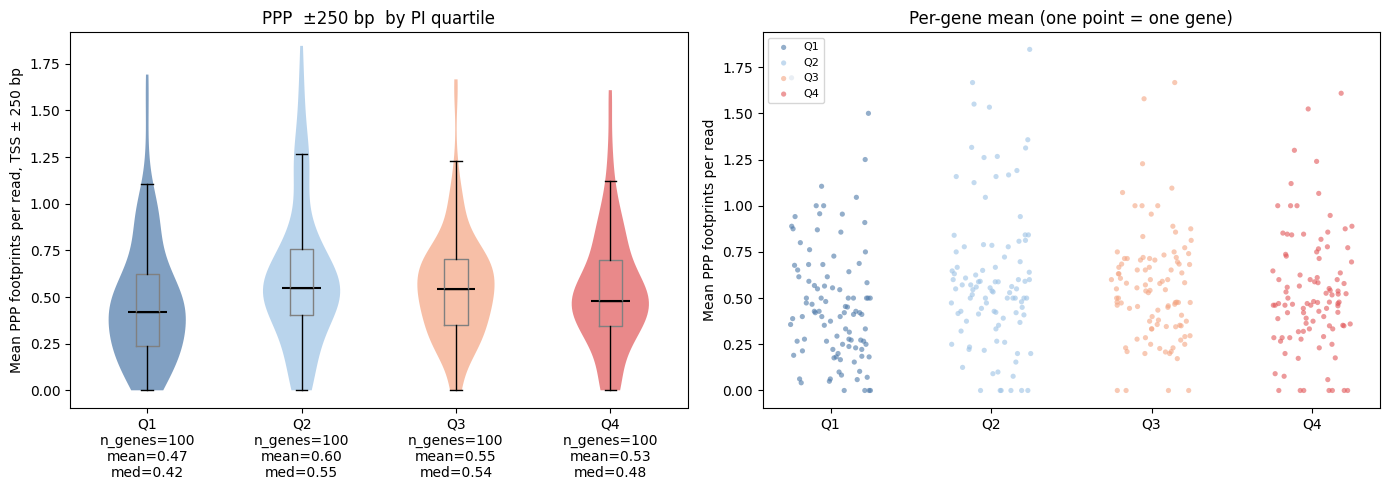

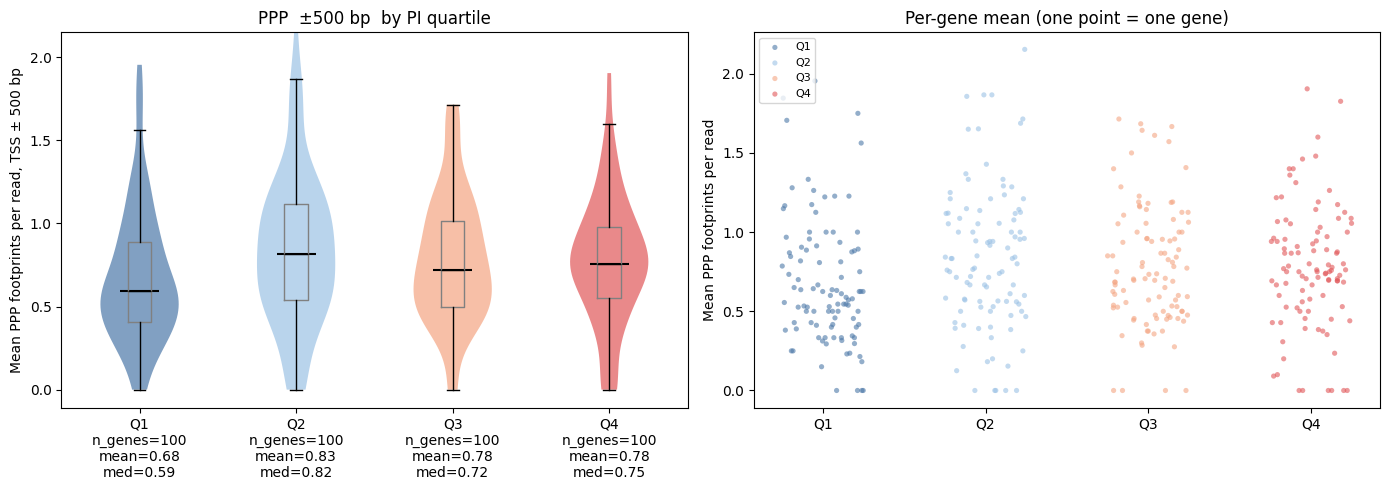

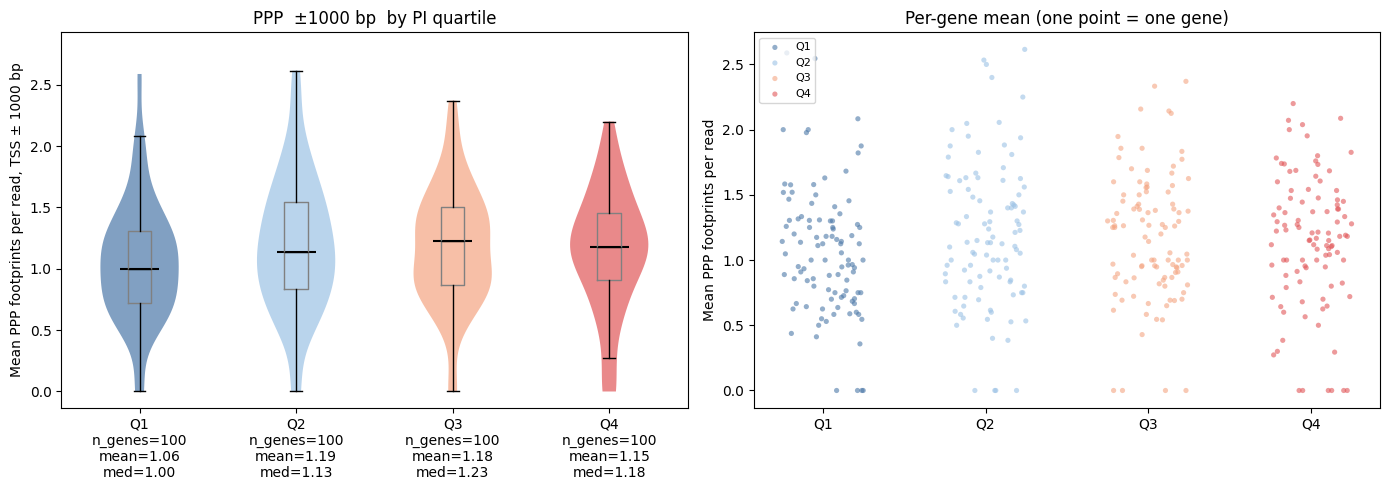

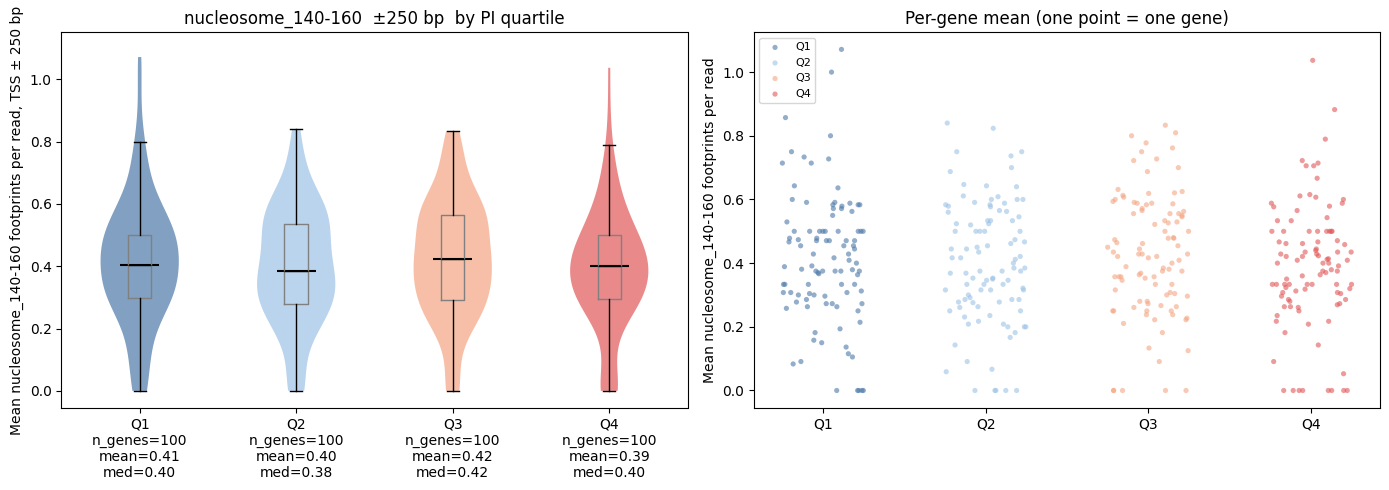

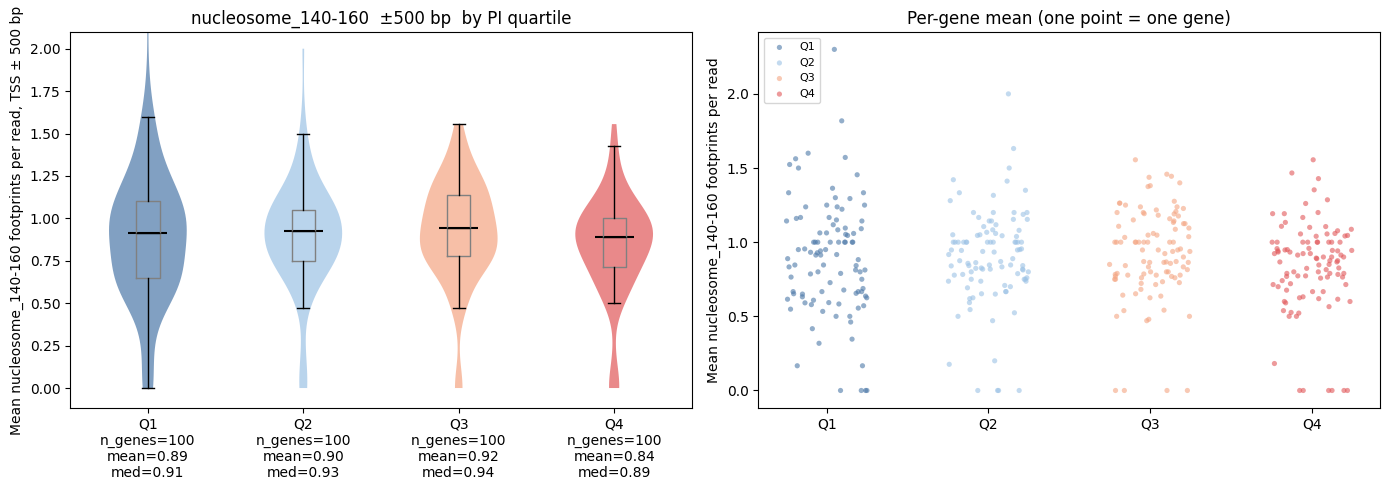

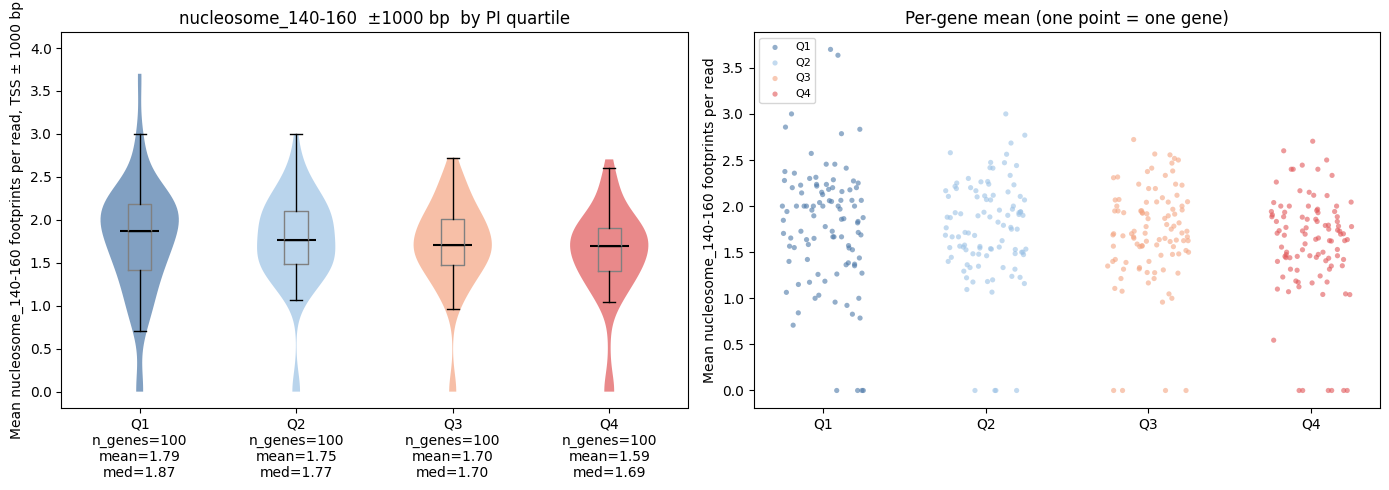

In [16]:
# Violin + per-gene scatter for each (footprint_type, window) config.
from scipy import stats
from itertools import combinations

PLOT_DIR = Path("/project/spott/cshan/fiber-seq/results/PolII/footprint_counts_positions/plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)


def plot_fp_counts(df, fp_type, window):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Collapse to one mean-footprints value per gene per quartile
    gene_summary = (
        df.groupby(["pi_quartile", "gene_name"])["n_footprints"]
        .mean().reset_index().rename(columns={"n_footprints": "mean_fp"})
    )

    group_data = {q: gene_summary.loc[gene_summary["pi_quartile"] == q, "mean_fp"].values
                  for q in quartiles}

    for i, q in enumerate(quartiles):
        data = group_data[q]
        if len(data) == 0:
            continue
        parts = axes[0].violinplot([data], positions=[i], showmedians=True, showextrema=False)
        for pc in parts["bodies"]:
            pc.set_facecolor(quartile_colors[q])
            pc.set_alpha(0.7)
        parts["cmedians"].set_color("black")
        axes[0].boxplot(
            [data], positions=[i], widths=0.15, showfliers=False,
            boxprops=dict(color="gray"), medianprops=dict(color="black"),
        )

    axes[0].set_xticks(range(len(quartiles)))
    axes[0].set_xticklabels([
        (f"{q}\nn_genes={len(group_data[q]):,}\nmean={group_data[q].mean():.2f}\n"
         f"med={np.median(group_data[q]):.2f}")
        if len(group_data[q]) else q
        for q in quartiles
    ])
    axes[0].set_ylabel(f"Mean {fp_type} footprints per read, TSS \u00b1 {window} bp")
    axes[0].set_title(f"{fp_type}  \u00b1{window} bp  by PI quartile")

    nonempty = [d for d in group_data.values() if len(d)]
    if nonempty:
        y_top = max(np.percentile(d, 99) for d in nonempty) * 1.15
        if y_top > 0:
            axes[0].set_ylim(top=y_top)

    rng = np.random.default_rng(0)
    for i, q in enumerate(quartiles):
        sub = gene_summary[gene_summary["pi_quartile"] == q]
        x = i + rng.uniform(-0.25, 0.25, len(sub))
        axes[1].scatter(x, sub["mean_fp"], color=quartile_colors[q],
                        alpha=0.6, s=14, edgecolor="none", label=q)
    axes[1].set_xticks(range(len(quartiles)))
    axes[1].set_xticklabels(quartiles)
    axes[1].set_ylabel(f"Mean {fp_type} footprints per read")
    axes[1].set_title("Per-gene mean (one point = one gene)")
    axes[1].legend(loc="upper left", fontsize=8)

    plt.tight_layout()
    fig.savefig(PLOT_DIR / f"{fp_type}_w{window}_{READ_FILTER}.png", dpi=300)
    plt.show()


for (fp_type, window), df in fp_count_tables.items():
    plot_fp_counts(df, fp_type, window)


### are the distribution of footprint counts differ between PI quartiles?

Pairwise Mann-Whitney U tests between quartiles for each footprint type and distance threshold (Wilcoxon rank-sum test, non-parametric)

- compares two independent samples to assess whether their population mean ranks differ
- null hypothesis: distributions of footprint counts are the same across quartiles
- significant p-value (< 0.05) suggests a difference in footprint count distributions between the quartiles
- do not require normal distribution, instead of directly comparing means, it compares the ranks of the data points --> If I randomly choose one gene from Q4 and one gene from Q1, what is the probability that the Q4 gene has more footprints than the Q1 gene? If this probability is significantly greater than 0.5, it suggests that Q4 genes tend to have more footprints than Q1 genes.

In [17]:
# Pairwise MWU per (footprint_type, window) config.
from scipy import stats
from itertools import combinations

# empty dictionary to hold the MWU results for each (footprint_type, window) config
mwu_results = {}
for (fp_type, window), df in fp_count_tables.items():
    print(f"=== {fp_type}  +/- {window} bp  (footprint counts by PI quartile) ===")
    for q in quartiles:
        d = df[df["pi_quartile"] == q]["n_footprints"]
        print(f"  {q}: n={len(d):,}, mean={d.mean():.2f}, median={d.median():.1f}")

# pairwise Mann-Whitney U tests between quartiles for this footprint type and window
    mwu_rows = []
    for q1, q2 in combinations(quartiles, 2):
        a = df[df["pi_quartile"] == q1]["n_footprints"]
        b = df[df["pi_quartile"] == q2]["n_footprints"]
        if len(a) == 0 or len(b) == 0:
            continue
        u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        mwu_rows.append({"q1": q1, "q2": q2, "U": u, "p": p})
    mwu_df = pd.DataFrame(mwu_rows)
    mwu_results[(fp_type, window)] = mwu_df

    print("Pairwise Mann-Whitney U (two-sided):")
    for _, r in mwu_df.iterrows():
        print(f"  {r['q1']} vs {r['q2']}: U={r['U']:,.0f}, p={r['p']:.2e}")
    print()

=== FIRE_nucleosome  +/- 250 bp  (footprint counts by PI quartile) ===
  Q1: n=1,836, mean=1.66, median=2.0
  Q2: n=1,866, mean=1.49, median=1.0
  Q3: n=2,013, mean=1.45, median=1.0
  Q4: n=1,987, mean=1.45, median=1.0
Pairwise Mann-Whitney U (two-sided):
  Q1 vs Q2: U=1,920,586, p=4.02e-12
  Q1 vs Q3: U=2,123,176, p=3.27e-18
  Q1 vs Q4: U=2,084,938, p=7.56e-17
  Q2 vs Q3: U=1,932,040, p=8.79e-02
  Q2 vs Q4: U=1,891,962, p=2.24e-01
  Q3 vs Q4: U=1,982,560, p=5.99e-01

=== FIRE_nucleosome  +/- 500 bp  (footprint counts by PI quartile) ===
  Q1: n=1,836, mean=3.83, median=4.0
  Q2: n=1,866, mean=3.61, median=4.0
  Q3: n=2,013, mean=3.60, median=4.0
  Q4: n=1,987, mean=3.58, median=4.0
Pairwise Mann-Whitney U (two-sided):
  Q1 vs Q2: U=1,909,608, p=3.14e-10
  Q1 vs Q3: U=2,078,835, p=2.45e-12
  Q1 vs Q4: U=2,075,734, p=1.03e-14
  Q2 vs Q3: U=1,889,370, p=7.35e-01
  Q2 vs Q4: U=1,885,240, p=3.40e-01
  Q3 vs Q4: U=2,020,930, p=5.43e-01

=== FIRE_nucleosome  +/- 1000 bp  (footprint counts by

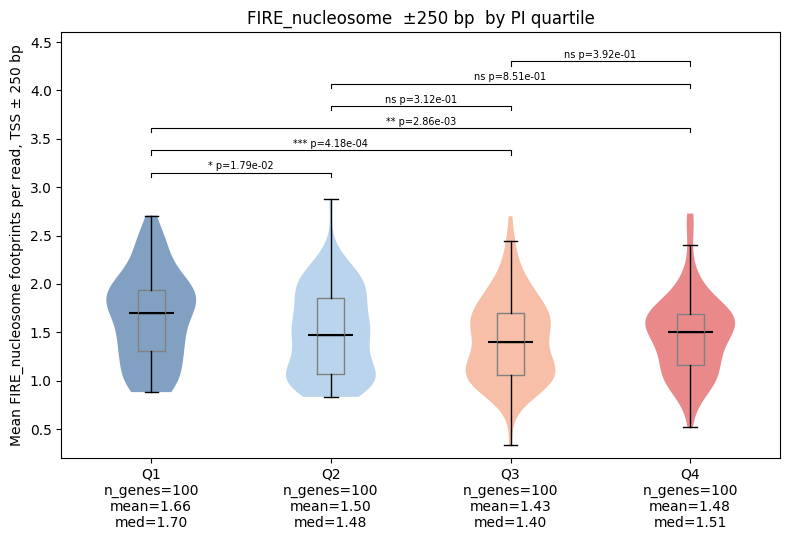

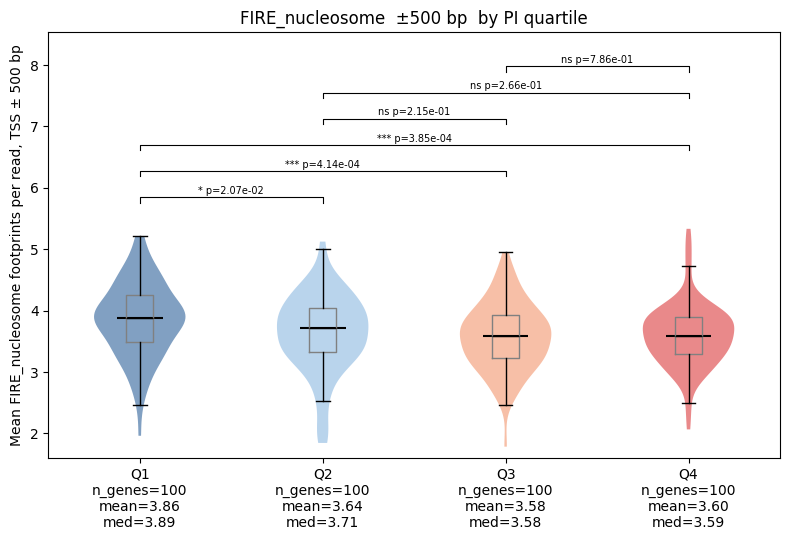

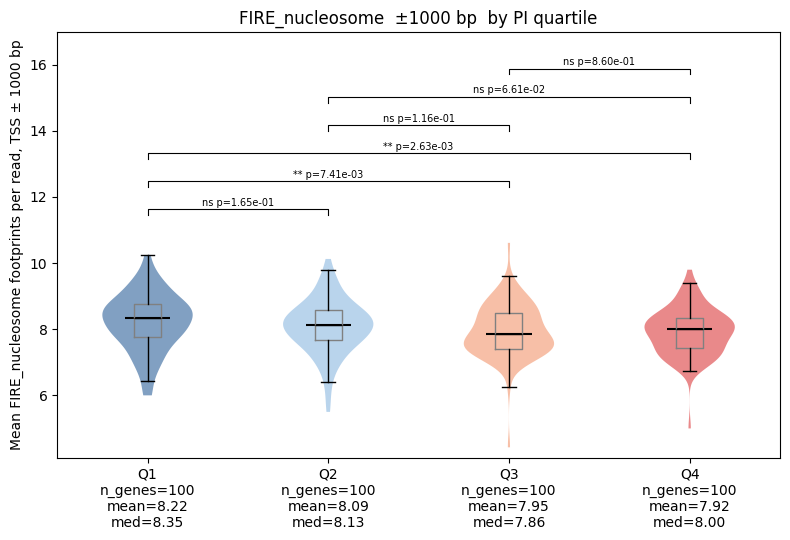

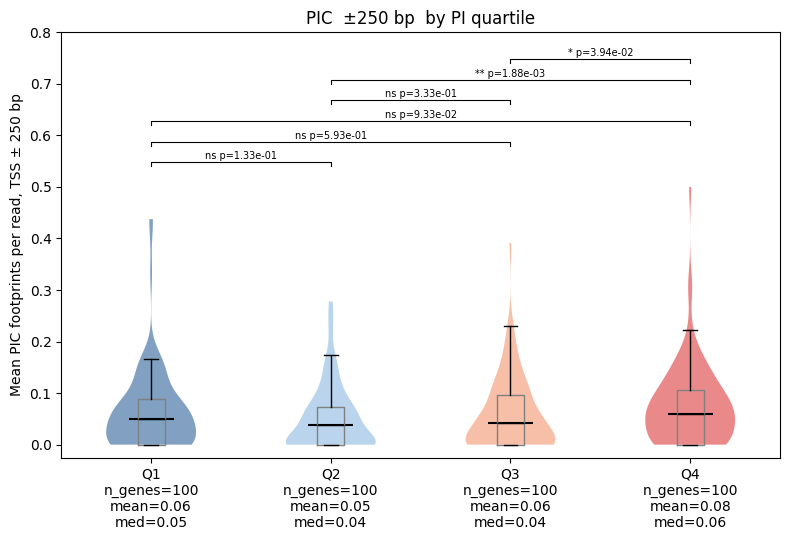

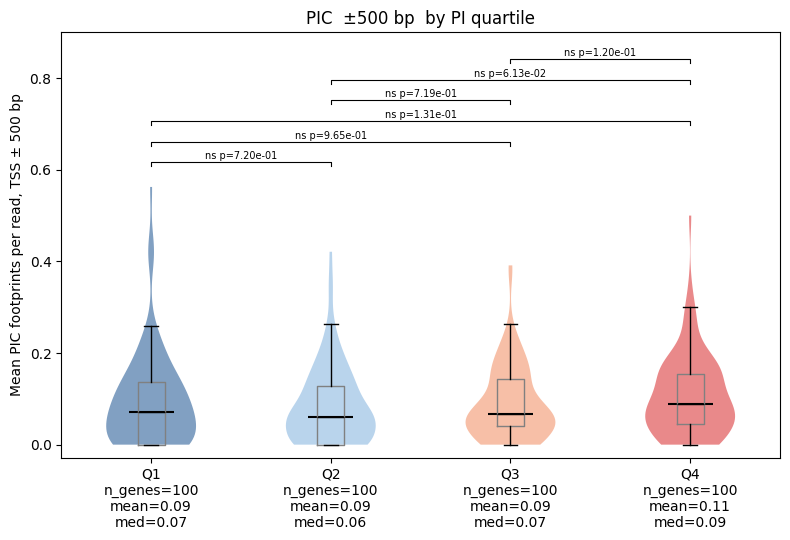

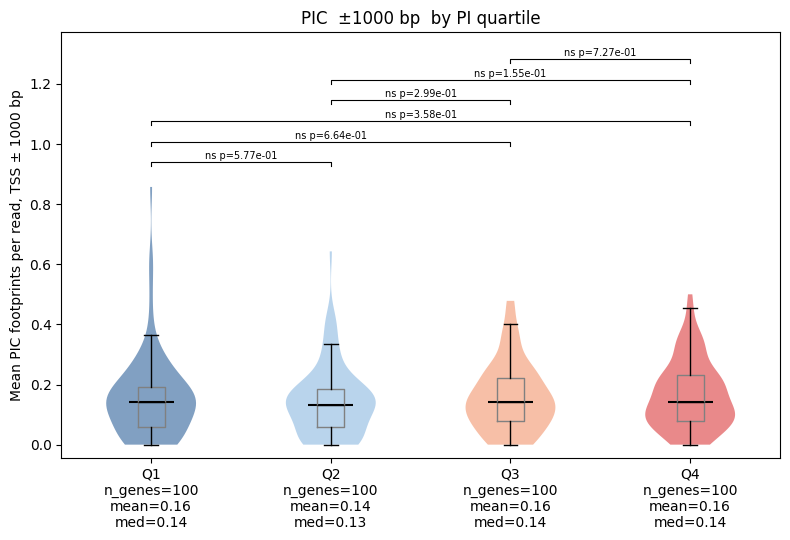

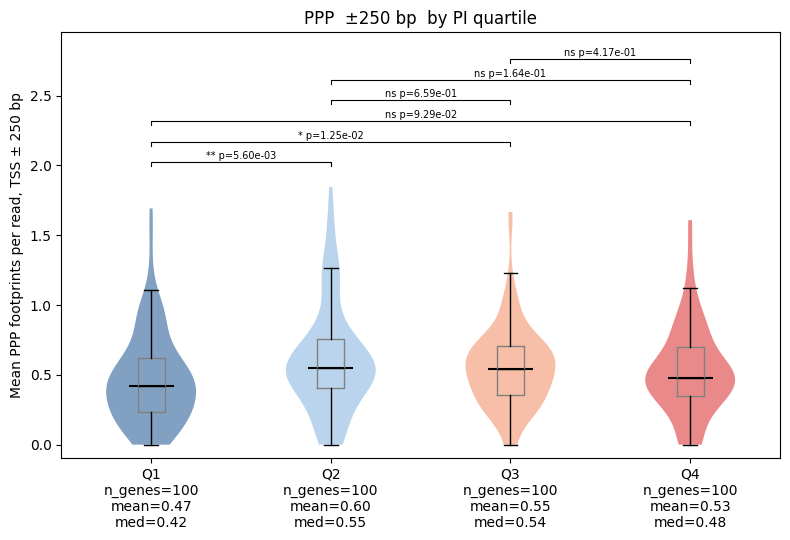

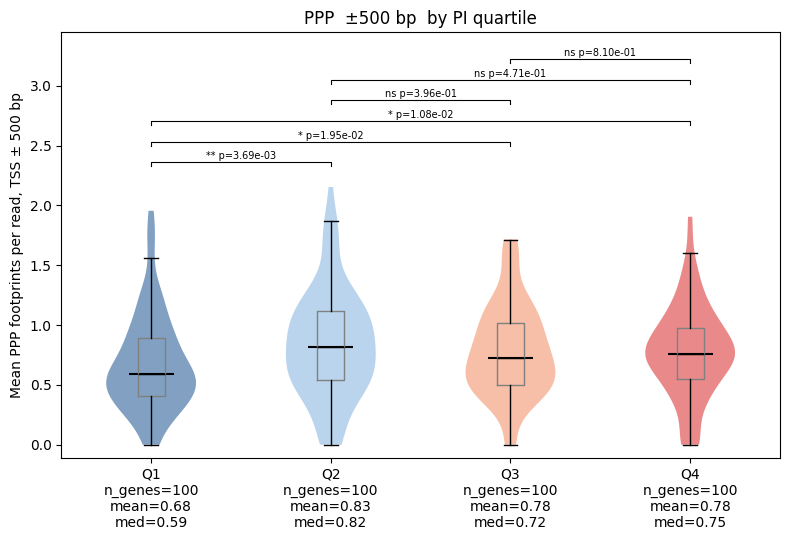

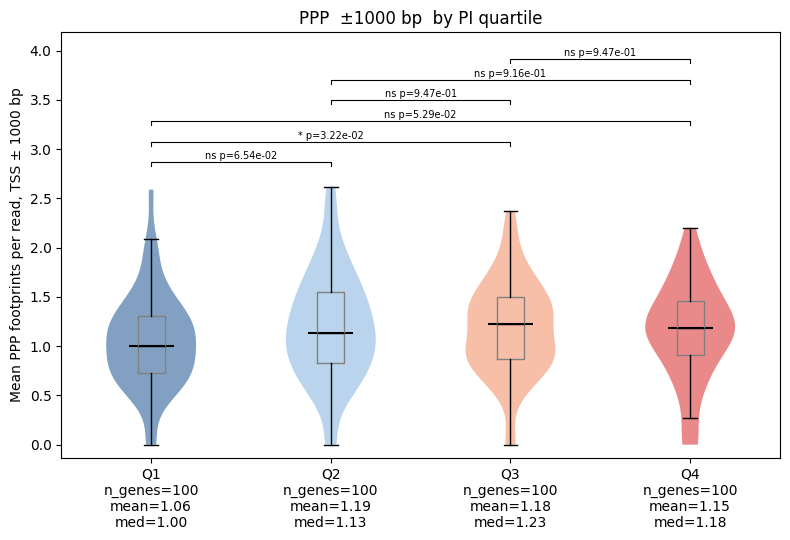

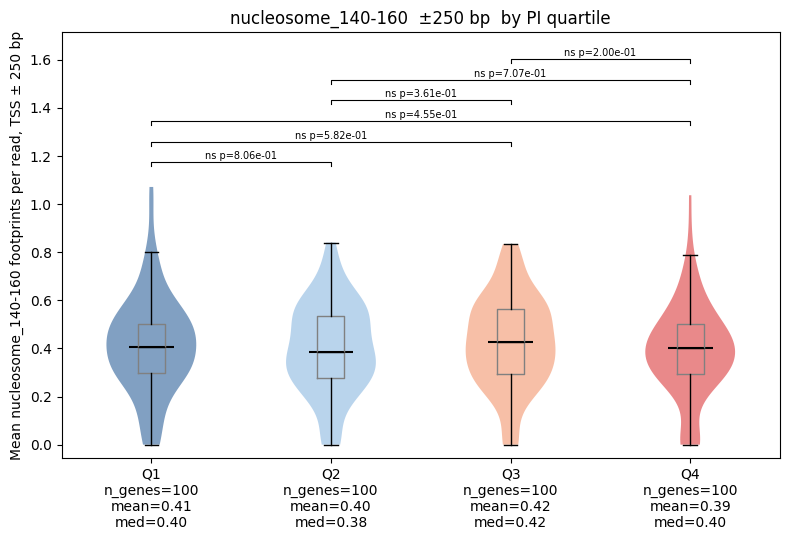

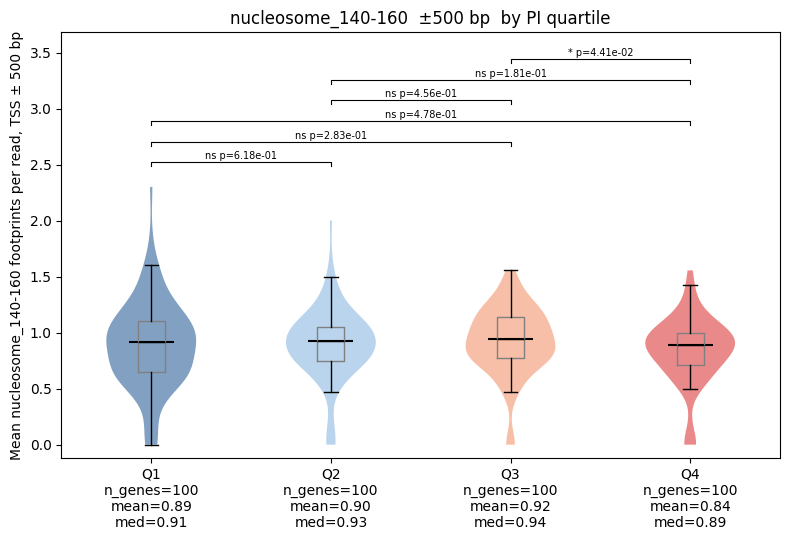

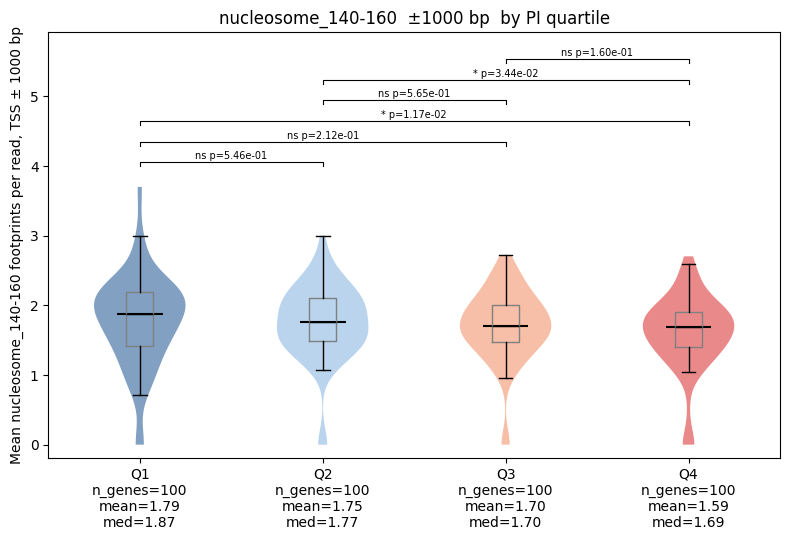

In [18]:
# Re-plot violins with pairwise Mann-Whitney p-values annotated above.
# Note: MWU here is on per-gene means (matches the violin's data), which
# differs from the per-read MWU printed in the previous cell.
# Significance stars: *** p<0.001, ** p<0.01, * p<0.05, ns otherwise.

def _sig_star(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"


def plot_fp_counts_with_pvals(df, fp_type, window):
    fig, ax = plt.subplots(figsize=(8, 5.5))

    gene_summary = (
        df.groupby(["pi_quartile", "gene_name"])["n_footprints"]
        .mean().reset_index().rename(columns={"n_footprints": "mean_fp"})
    )
    group_data = {q: gene_summary.loc[gene_summary["pi_quartile"] == q, "mean_fp"].values
                  for q in quartiles}

    for i, q in enumerate(quartiles):
        data = group_data[q]
        if len(data) == 0:
            continue
        parts = ax.violinplot([data], positions=[i], showmedians=True, showextrema=False)
        for pc in parts["bodies"]:
            pc.set_facecolor(quartile_colors[q])
            pc.set_alpha(0.7)
        parts["cmedians"].set_color("black")
        ax.boxplot(
            [data], positions=[i], widths=0.15, showfliers=False,
            boxprops=dict(color="gray"), medianprops=dict(color="black"),
        )

    ax.set_xticks(range(len(quartiles)))
    ax.set_xticklabels([
        (f"{q}\nn_genes={len(group_data[q]):,}\nmean={group_data[q].mean():.2f}\n"
         f"med={np.median(group_data[q]):.2f}")
        if len(group_data[q]) else q
        for q in quartiles
    ])
    ax.set_ylabel(f"Mean {fp_type} footprints per read, TSS ± {window} bp")
    ax.set_title(f"{fp_type}  ±{window} bp  by PI quartile")

    # Pairwise MWU on per-gene means (matches the violin's data)
    pair_pvals = []
    for q1, q2 in combinations(quartiles, 2):
        a, b = group_data[q1], group_data[q2]
        if len(a) == 0 or len(b) == 0:
            continue
        _, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        pair_pvals.append((q1, q2, p))

    nonempty = [d for d in group_data.values() if len(d)]
    if nonempty and pair_pvals:
        y0   = max(d.max() for d in nonempty)
        step = y0 * 0.08
        ax.set_ylim(top=y0 + step * (len(pair_pvals) + 1.5))
        for k, (q1, q2, p) in enumerate(pair_pvals):
            i1, i2 = quartiles.index(q1), quartiles.index(q2)
            y = y0 + step * (k + 1)
            ax.plot([i1, i1, i2, i2],
                    [y, y + step * 0.2, y + step * 0.2, y],
                    lw=0.8, color="black")
            ax.text((i1 + i2) / 2, y + step * 0.25,
                    f"{_sig_star(p)} p={p:.2e}",
                    ha="center", va="bottom", fontsize=7)

    plt.tight_layout()
    fig.savefig(PLOT_DIR / f"{fp_type}_w{window}_{READ_FILTER}_pvals.png", dpi=300)
    plt.show()


for (fp_type, window), df in fp_count_tables.items():
    plot_fp_counts_with_pvals(df, fp_type, window)


### Spatial distribution of footprint midpoints relative to TSS

Load footprint positions from tabix-indexed BED files and compute each midpoint's distance to TSS (strand-oriented so positive = downstream).

In [21]:
# Per-gene TSS info (one row per gene)
tss_info = (
    selected_acc[["gene_name", "chromosome", "tss_coordinate", "tss_strand", "PI"]]
    .dropna(subset=["chromosome", "tss_coordinate", "tss_strand", "PI"])
    .drop_duplicates(subset="gene_name")
    .reset_index(drop=True)
)
tss_info["pi_quartile"] = tss_info["gene_name"].map(gene_to_quartile)

print(f"TSS coords for {len(tss_info)} genes")
print(tss_info.groupby("pi_quartile", observed=True).size().to_string())

TSS coords for 400 genes
pi_quartile
Q1    100
Q2    100
Q3    100
Q4    100


1. load footprint midpoints for every footprint type (FIRE nucleosome, PIC, PPP, nucleosome_140-160) from the corresponding BED files
2. for each selected read-TSS pair, compute the distance of each footprint midpoint to the TSS (strand-oriented)
3. aggregate these distances across all reads in each quartile to get the distribution of footprint positions relative to TSS for each quartile
4. visualize as density plots or cumulative distribution functions (CDFs) to compare the spatial patterns of footprints across quartiles

In [ ]:
# Load footprint midpoints per (type, window): one row per midpoint with strand-
# oriented `rel_position` (positive = downstream). 
# "accessible" drops footprints from inaccessible reads. Saves a parquet per
# config to POS_OUT_DIR and stores all 12 DataFrames in `fp_positions_by_config`.
#
# Accessibility source: same FIRE-all 31-sample table used by cell 35
# (`access_df` was built there by renaming tss_accessible_fire -> tss_accessible).
from pathlib import Path

POS_OUT_DIR = Path("/project/spott/cshan/fiber-seq/results/PolII/accessibility_and_promoter_pausing")
POS_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Per-gene set of accessible read_cores (only used when READ_FILTER == "accessible").
# `access_df` is the 31-sample FIRE-all frame with tss_accessible_fire renamed.
if READ_FILTER == "accessible":
    _acc = access_df[access_df["tss_accessible"].astype(bool)].copy()
    _acc["read_core"] = _acc["read_id"].astype(str).map(_read_core)
    accessible_read_cores_by_gene = (
        _acc.groupby("gene_name")["read_core"].apply(set).to_dict()
    )
elif READ_FILTER == "all":
    accessible_read_cores_by_gene = None
else:
    raise ValueError(f"unknown READ_FILTER: {READ_FILTER!r}")

# Loads footprint midpoints from the bed files for the TSS in tss_info, keeping only footprints that overlap TSS +/- window 
# and (if accessible_by_gene is not None) belong to reads in the accessible set for that gene. Returns a DataFrame with one row per footprint and a list of any missing bed files.
def load_fp_positions(tss_info, fp_type, window, accessible_by_gene):
    fp_bed_dir = FP_BED_ROOT / fp_type
    rows = []
    missing = []
    for _, row in tss_info.iterrows():
        gene  = row["gene_name"]
        chrom = row["chromosome"]
        tss   = int(row["tss_coordinate"])
        strand = row["tss_strand"]
        quartile = row["pi_quartile"]
        bed_path = fp_bed_dir / f"{chrom}_footprints.bed.gz"
        if not bed_path.exists():
            missing.append(str(bed_path))
            continue

        gene_acc = (accessible_by_gene.get(gene, set())
                    if accessible_by_gene is not None else None)

        tbx = pysam.TabixFile(str(bed_path))
        try:
            for rec in tbx.fetch(chrom, max(0, tss - window), tss + window):
                fields = rec.split("\t")
                read_core = fields[3]
                if gene_acc is not None and read_core not in gene_acc:
                    continue
                fp_mid = float(fields[5])
                rel_pos = (fp_mid - tss) if strand == "+" else (tss - fp_mid)
                rows.append({
                    "gene_name":    gene,
                    "pi_quartile":  quartile,
                    "read_id":      read_core,
                    "midpoint":     fp_mid,
                    "rel_position": rel_pos,
                })
        except (ValueError, KeyError):
            pass
        tbx.close()
    return pd.DataFrame(rows), missing


fp_positions_by_config = {}
for fp_type in FP_TYPES:
    for w in WINDOWS:
        df, missing = load_fp_positions(
            tss_info, fp_type, w, accessible_read_cores_by_gene
        )
        out_path = POS_OUT_DIR / f"{fp_type}_w{w}_{READ_FILTER}_fire_all.parquet"
        df.to_parquet(out_path, index=False)
        fp_positions_by_config[(fp_type, w)] = df
        if missing:
            print(f"  [WARN] {fp_type} w{w}: {len(missing)} BED files missing "
                  f"(e.g. {missing[0]})")
        print(f"{fp_type:>22}  +/- {w:>4} bp  midpoints={len(df):>9,}  -> {out_path.name}")

takes individual footprint midpoint table and convert it to gene x binned position count table
- for each gene, for each footprint type, for each distance bin (e.g. -1000 to -900, -900 to -800, ..., 900 to 1000), count the number of footprints that fall into that bin across all reads assigned to that gene

In [ ]:
# ---- gene-TSS level per-bp count tables (no binning) -----------------------
# Builds one row per gene with one column per integer rel-TSS position
# (bin_-1000 .. bin_999 for w=1000). Downstream cells use `bin_cols` /
# `bin_centers` from `_bin_cols_centers`, so dropping to BIN_WIDTH=1 is enough
# to turn every plot/stat into a per-bp version.
PLOT_OUT_DIR = Path("/project/spott/cshan/fiber-seq/results/PolII/footprints_distribution")
PLOT_OUT_DIR.mkdir(parents=True, exist_ok=True)

BIN_WIDTH = 1  # bp; per-base resolution

# helper to extract bin column names and their center positions from a binned DataFrame (bin_NNN where NNN is the left edge) and return them as arrays
def _bin_cols_centers(binned):
    bin_cols = [c for c in binned.columns if c.startswith("bin_")]
    bin_lefts = np.array([int(c[4:]) for c in bin_cols])
    bin_centers = bin_lefts + BIN_WIDTH / 2  # = bin_lefts + 0.5 when BIN_WIDTH=1
    return bin_cols, bin_centers


def build_gene_binned(fp_positions, tss_info, window, bin_width=BIN_WIDTH):
    """One row per gene; columns are per-bp counts at rel-TSS positions
    in [-window, window). Column names use the integer left edge (`bin_<int>`),
    so when bin_width=1 each column corresponds to a single bp."""
    bin_edges = np.arange(-window, window + bin_width, bin_width)
    bin_lefts = bin_edges[:-1]
    n_bins = len(bin_lefts)

    gene_order = tss_info["gene_name"].tolist()
    gene_to_idx = {g: i for i, g in enumerate(gene_order)}
    counts = np.zeros((len(gene_order), n_bins), dtype=np.int32)

    pos = fp_positions["rel_position"].to_numpy()
    in_window = (pos >= -window) & (pos < window)
    if in_window.any():
        sub = fp_positions.loc[in_window, ["gene_name", "rel_position"]]
        bin_idx = ((sub["rel_position"].to_numpy() - bin_edges[0]) // bin_width).astype(int)
        gene_idx = sub["gene_name"].map(gene_to_idx).to_numpy()
        valid = (~pd.isna(gene_idx)) & (bin_idx >= 0) & (bin_idx < n_bins)
        np.add.at(counts, (gene_idx[valid].astype(int), bin_idx[valid]), 1)

    bin_cols = [f"bin_{int(e)}" for e in bin_lefts]
    df = pd.DataFrame(counts, columns=bin_cols)
    df.insert(0, "gene_name", gene_order)
    df["PI"] = df["gene_name"].map(tss_info.set_index("gene_name")["PI"])
    df["pi_quartile"] = df["gene_name"].map(gene_to_quartile)
    return df


fp_binned_by_config = {}
for (fp_type, w), df_pos in fp_positions_by_config.items():
    binned = build_gene_binned(df_pos, tss_info, w)
    fp_binned_by_config[(fp_type, w)] = binned
    out = POS_OUT_DIR / f"{fp_type}_w{w}_{READ_FILTER}_fire_all_perbp.parquet"
    binned.to_parquet(out, index=False)
    n_bins = sum(c.startswith("bin_") for c in binned.columns)
    print(f"{fp_type:>22}  +/- {w} bp  per-bp: {binned.shape[0]} genes x {n_bins} positions  -> {out.name}")

In [ ]:
# Per-bp total footprint count by PI quartile (no binning; sum across genes/reads),
# faceted by (footprint_type, window). Saves PNG to PLOT_OUT_DIR.
n_rows, n_cols = len(FP_TYPES), len(WINDOWS)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))

for i, fp_type in enumerate(FP_TYPES):
    for j, w in enumerate(WINDOWS):
        ax = axes[i, j]
        binned = fp_binned_by_config[(fp_type, w)]
        bin_cols, bin_centers = _bin_cols_centers(binned)
        for q in quartiles:
            sub = binned[binned["pi_quartile"] == q]
            total_profile = sub[bin_cols].sum(axis=0).to_numpy()
            ax.plot(bin_centers, total_profile, color=quartile_colors[q], lw=0.8, label=q)
        ax.axvline(0, color="black", ls="--", lw=0.8, alpha=0.5)
        ax.set_title(f"{fp_type}  +/- {w} bp", fontsize=9)
        if i == n_rows - 1:
            ax.set_xlabel("rel TSS (bp)")
        if j == 0:
            ax.set_ylabel("Total fp count\n(sum across reads & genes, per bp)")
        ax.tick_params(labelsize=8)

handles = [mpatches.Patch(color=quartile_colors[q], label=q) for q in quartiles]
fig.legend(handles=handles, loc="upper center", ncol=len(quartiles),
           bbox_to_anchor=(0.5, 1.02), frameon=False)
plt.tight_layout()
fig.savefig(PLOT_OUT_DIR / "total_profile_by_quartile_perbp.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# Inspect one per-bp parquet and summarize total-profile trends by (fp_type, window, quartile).
# Reads FIRE-all per-bp parquets from the same location they were written above.
from pathlib import Path

POS_OUT_DIR = Path("/project/spott/cshan/fiber-seq/results/PolII/accessibility_and_promoter_pausing")
FP_TYPES = ["FIRE_nucleosome", "PIC", "PPP", "nucleosome_140-160"]
WINDOWS = [250, 500, 1000]
READ_FILTER = "accessible"
BIN_WIDTH = 1

if "quartiles" not in globals():
    quartiles = ["Q1", "Q2", "Q3", "Q4"]

if "_bin_cols_centers" not in globals():
    def _bin_cols_centers(binned):
        bin_cols = [c for c in binned.columns if c.startswith("bin_")]
        bin_lefts = np.array([int(c[4:]) for c in bin_cols])
        bin_centers = bin_lefts + BIN_WIDTH / 2
        return bin_cols, bin_centers

example_path = POS_OUT_DIR / f"{FP_TYPES[0]}_w{WINDOWS[0]}_{READ_FILTER}_fire_all_perbp.parquet"
example = pd.read_parquet(example_path)
print("Example parquet:", example_path)
print(example.head().to_string(index=False))
print("Columns:", ", ".join(example.columns[:12]), "...")

# Load per-bp tables if they are not already in memory.
if "fp_binned_by_config" not in globals() or not fp_binned_by_config:
    fp_binned_by_config = {}
    for fp_type in FP_TYPES:
        for w in WINDOWS:
            path = POS_OUT_DIR / f"{fp_type}_w{w}_{READ_FILTER}_fire_all_perbp.parquet"
            if path.exists():
                fp_binned_by_config[(fp_type, w)] = pd.read_parquet(path)

# Total profile per (fp_type, window, quartile): peak position and center-of-mass
# now computed on per-bp summed counts (sum across genes & reads).
trend_rows = []
for (fp_type, w), binned in fp_binned_by_config.items():
    bin_cols, bin_centers = _bin_cols_centers(binned)
    for q in quartiles:
        sub = binned[binned["pi_quartile"] == q]
        if sub.empty:
            continue
        total_profile = sub[bin_cols].sum(axis=0).to_numpy()
        total = total_profile.sum()
        if total <= 0:
            peak = np.nan
            com = np.nan
            mean_abs = np.nan
        else:
            peak = float(bin_centers[np.argmax(total_profile)])
            com = float((total_profile * bin_centers).sum() / total)
            mean_abs = float((total_profile * np.abs(bin_centers)).sum() / total)
        trend_rows.append({
            "fp_type": fp_type,
            "window": w,
            "pi_quartile": q,
            "peak_pos": peak,
            "center_of_mass": com,
            "mean_abs_pos": mean_abs,
            "total_count": float(total),
        })

trend_df = pd.DataFrame(trend_rows).sort_values(["fp_type", "window", "pi_quartile"])
trend_df

# Quick view of window-size trends in mean abs position per footprint class + quartile
trend_pivot = trend_df.pivot_table(
    index=["fp_type", "pi_quartile"],
    columns="window",
    values="mean_abs_pos"
).sort_index()
trend_pivot

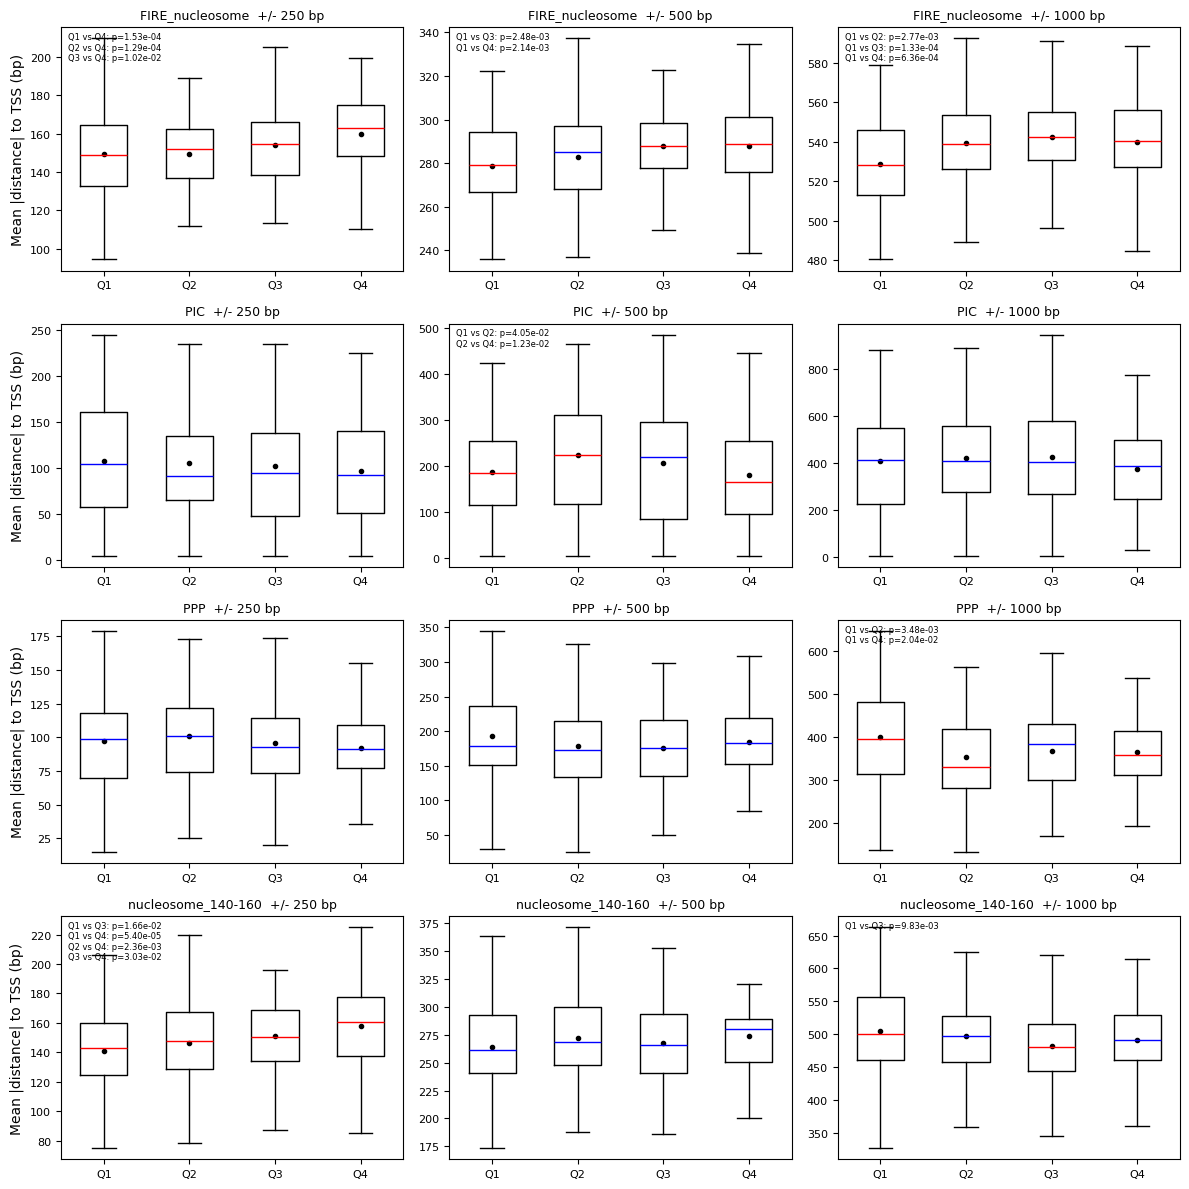

In [10]:
# Test quartile differences in per-gene mean |distance| and plot by footprint type + window.
from itertools import combinations
from scipy.stats import mannwhitneyu

if "quartiles" not in globals():
    quartiles = ["Q1", "Q2", "Q3", "Q4"]

if "_bin_cols_centers" not in globals():
    def _bin_cols_centers(binned):
        bin_cols = [c for c in binned.columns if c.startswith("bin_")]
        bin_lefts = np.array([int(c[4:]) for c in bin_cols])
        bin_centers = bin_lefts + BIN_WIDTH / 2
        return bin_cols, bin_centers


def per_gene_mean_abs(binned):
    bin_cols, bin_centers = _bin_cols_centers(binned)
    counts = binned[bin_cols].to_numpy().astype(float)
    total = counts.sum(axis=1)
    with np.errstate(invalid="ignore", divide="ignore"):
        mean_abs = np.where(
            total > 0,
            (counts * np.abs(bin_centers)).sum(axis=1) / total,
            np.nan,
        )
    return pd.DataFrame({
        "gene_name": binned["gene_name"].to_numpy(),
        "pi_quartile": binned["pi_quartile"].to_numpy(),
        "mean_abs_pos": mean_abs,
    })

# Build per-gene distance table for all configs.
per_gene_rows = []
for (fp_type, w), binned in fp_binned_by_config.items():
    g = per_gene_mean_abs(binned)
    g["fp_type"] = fp_type
    g["window"] = w
    per_gene_rows.append(g)
per_gene_df = pd.concat(per_gene_rows, ignore_index=True)

# Pairwise MWU tests per (fp_type, window).
p_rows = []
for fp_type in FP_TYPES:
    for w in WINDOWS:
        sub = per_gene_df[(per_gene_df["fp_type"] == fp_type) & (per_gene_df["window"] == w)]
        for q1, q2 in combinations(quartiles, 2):
            a = sub.loc[sub["pi_quartile"] == q1, "mean_abs_pos"].dropna().to_numpy()
            b = sub.loc[sub["pi_quartile"] == q2, "mean_abs_pos"].dropna().to_numpy()
            if len(a) == 0 or len(b) == 0:
                continue
            u, p = mannwhitneyu(a, b, alternative="two-sided")
            p_rows.append({
                "fp_type": fp_type,
                "window": w,
                "q1": q1,
                "q2": q2,
                "n1": len(a),
                "n2": len(b),
                "U": u,
                "p": p,
            })

pvals_df = pd.DataFrame(p_rows).sort_values(["fp_type", "window", "q1", "q2"])
pvals_df

p_lookup = {
    (r.fp_type, r.window, r.q1, r.q2): r.p
    for r in pvals_df.itertuples(index=False)
}

# Plot per-gene mean |distance| by quartile for each footprint type and window.
rows, cols = len(FP_TYPES), len(WINDOWS)
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows), sharey=False)

for i, fp_type in enumerate(FP_TYPES):
    for j, w in enumerate(WINDOWS):
        ax = axes[i, j]
        sub = per_gene_df[(per_gene_df["fp_type"] == fp_type) & (per_gene_df["window"] == w)]
        data = [sub.loc[sub["pi_quartile"] == q, "mean_abs_pos"].dropna().to_numpy() for q in quartiles]

        sig_pairs = []
        sig_quartiles = set()
        for q1, q2 in combinations(quartiles, 2):
            p = p_lookup.get((fp_type, w, q1, q2))
            if p is None:
                continue
            if p < 0.05:
                sig_pairs.append((q1, q2, p))
                sig_quartiles.update([q1, q2])

        bp = ax.boxplot(data, widths=0.55, showfliers=False)
        means = [np.nanmean(d) if len(d) else np.nan for d in data]
        ax.plot(range(1, len(quartiles) + 1), means, "o", color="black", markersize=3)

        for idx, med in enumerate(bp["medians"]):
            med.set_color("blue")
            if quartiles[idx] in sig_quartiles:
                med.set_color("red")

        ax.set_xticks(range(1, len(quartiles) + 1))
        ax.set_xticklabels(quartiles)
        ax.set_title(f"{fp_type}  +/- {w} bp", fontsize=9)
        if j == 0:
            ax.set_ylabel("Mean |distance| to TSS (bp)")
        ax.tick_params(labelsize=8)

        if sig_pairs:
            sig_lines = [f"{q1} vs {q2}: p={p:.2e}" for q1, q2, p in sig_pairs]
            ax.text(
                0.02, 0.98,
                "\n".join(sig_lines),
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=6,
            )

plt.tight_layout()
plt.show()


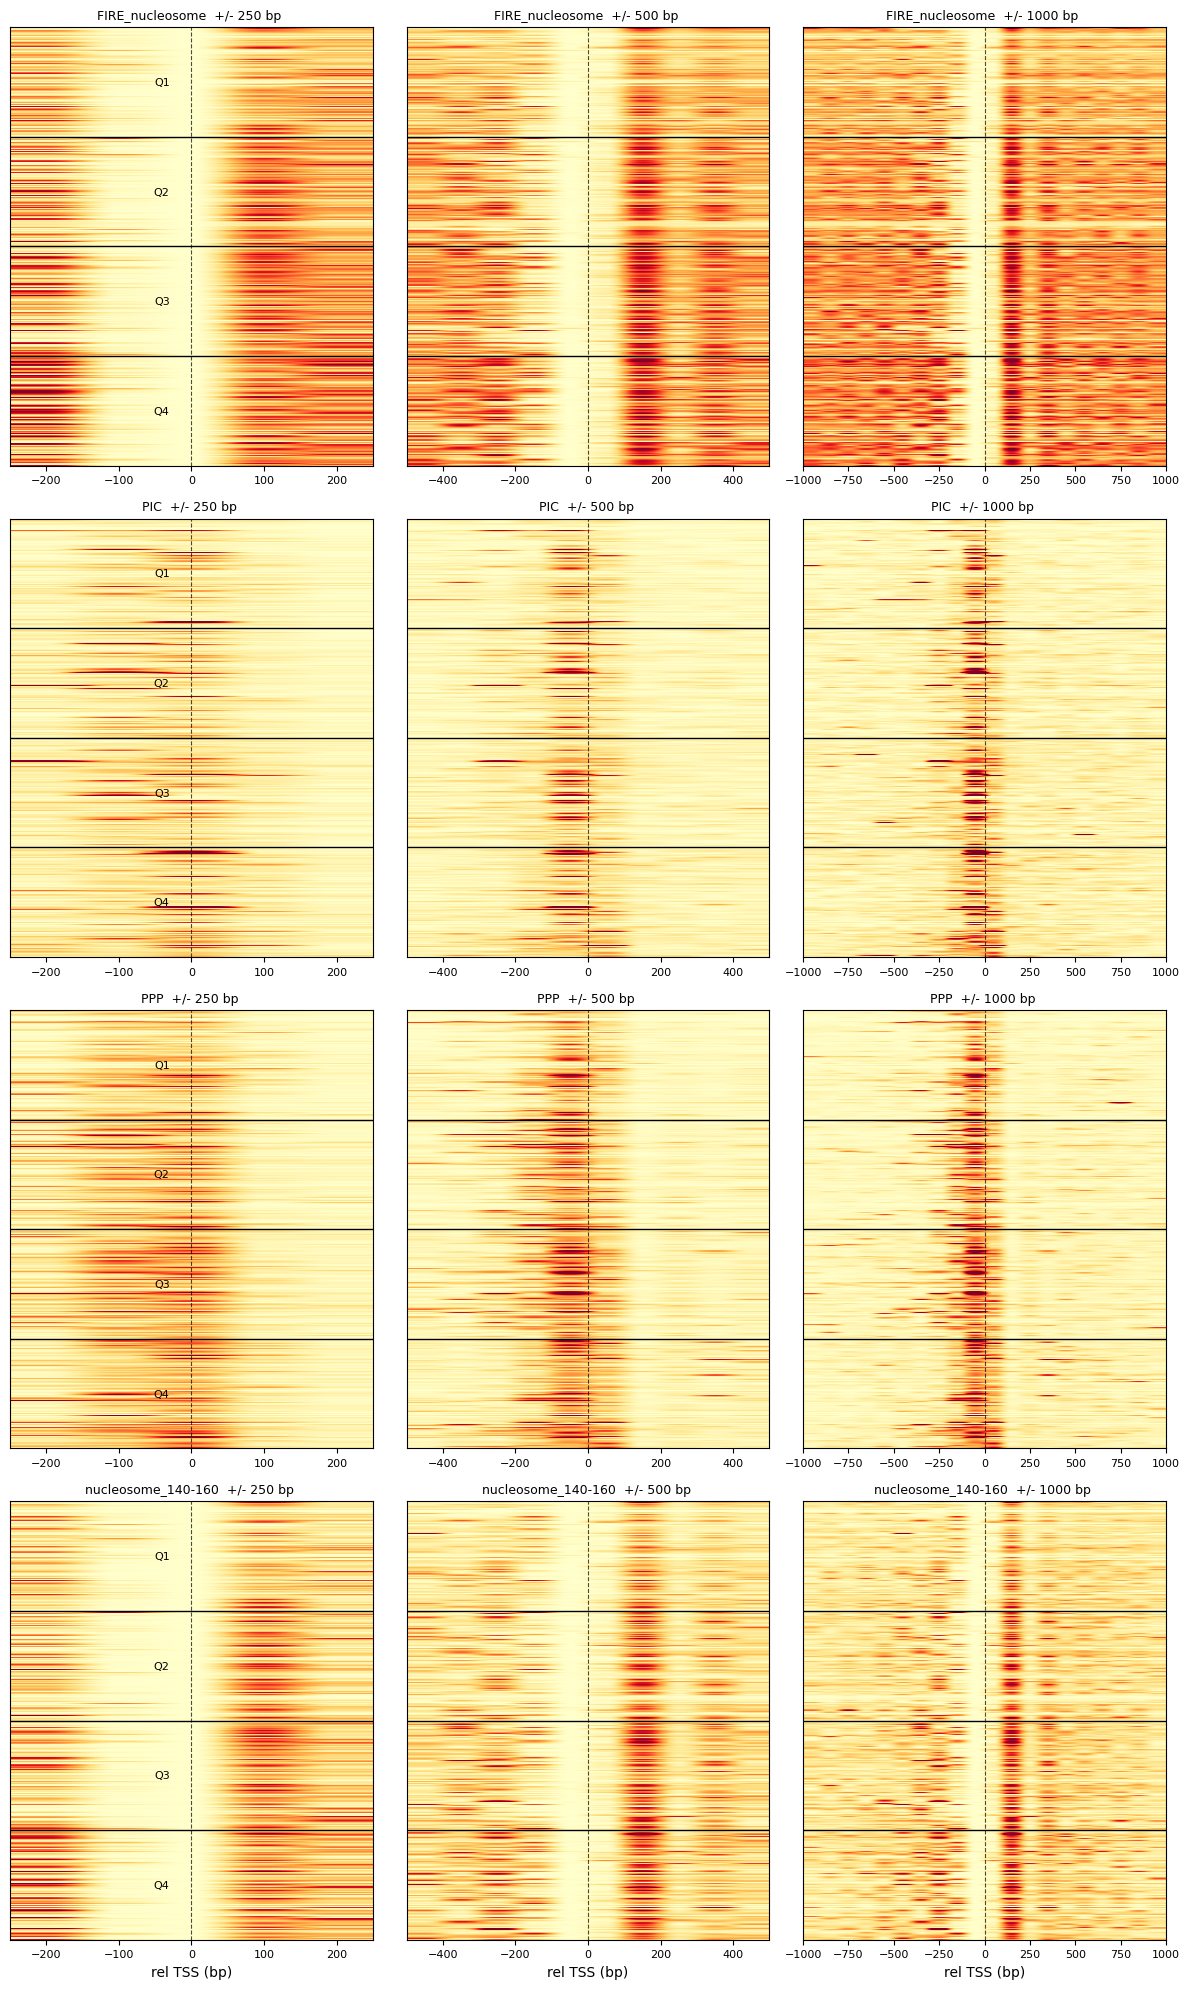

In [40]:
# Per-gene total-count heatmap (10-bp bins, no row normalization).
# Re-aggregates the per-bp parquets to 10-bp bins on the fly for display only;
# the underlying parquets stay per-bp. Color = absolute footprint count per
# gene per 10-bp bin, clipped at the 99th percentile to keep the colormap useful.
HEATMAP_BIN = 10  # bp; display only

n_rows, n_cols = len(FP_TYPES), len(WINDOWS)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 5 * n_rows))

gene_order = []
for q in quartiles:
    sub = tss_info[tss_info["pi_quartile"] == q].sort_values("PI")
    gene_order.extend(sub["gene_name"].tolist())

quartile_offsets = []
running = 0
for q in quartiles:
    quartile_offsets.append((q, running, len(quartile_to_genes[q])))
    running += len(quartile_to_genes[q])

for i, fp_type in enumerate(FP_TYPES):
    for j, w in enumerate(WINDOWS):
        ax = axes[i, j]
        binned = fp_binned_by_config[(fp_type, w)].set_index("gene_name")
        bin_cols, _ = _bin_cols_centers(binned.reset_index())
        mat = binned.loc[gene_order, bin_cols].to_numpy().astype(float)
        # Re-bin to HEATMAP_BIN-bp sums (drops trailing partial bin if any).
        n_keep = (mat.shape[1] // HEATMAP_BIN) * HEATMAP_BIN
        mat_disp = mat[:, :n_keep].reshape(mat.shape[0], -1, HEATMAP_BIN).sum(axis=2)
        vmax = np.quantile(mat_disp[mat_disp > 0], 0.99) if (mat_disp > 0).any() else 1.0
        ax.imshow(mat_disp, aspect="auto", cmap="YlOrRd", vmin=0, vmax=vmax,
                  extent=[-w, w, len(gene_order) - 0.5, -0.5])
        ax.axvline(0, color="black", ls="--", lw=0.8, alpha=0.7)
        for q, start, _ in quartile_offsets:
            if start > 0:
                ax.axhline(start - 0.5, color="black", lw=1.0)
        ax.set_yticks([])
        ax.set_title(f"{fp_type}  +/- {w} bp ", fontsize=9)
        if i == n_rows - 1:
            ax.set_xlabel("rel TSS (bp)")
        ax.tick_params(labelsize=8)

for i in range(n_rows):
    ax = axes[i, 0]
    for q, start, n in quartile_offsets:
        ax.text(-0.06 * 2 * WINDOWS[0], start + n / 2 - 0.5, q,
                fontsize=8, va="center", ha="right",
                transform=ax.transData)

plt.tight_layout()
fig.savefig(PLOT_OUT_DIR / "per_gene_total_count_heatmap_10bp.png", dpi=200, bbox_inches="tight")
plt.show()

In [25]:
# Pairwise KS + MWU on per-gene summary stats across PI quartiles,
# for every (footprint_type, window). Per-gene mean rel_position and
# mean |rel_position| are weighted by bin counts (gene = one observation).
from scipy import stats
from itertools import combinations


def per_gene_stats(binned):
    bin_cols, bin_centers = _bin_cols_centers(binned)
    counts = binned[bin_cols].to_numpy().astype(float)
    total = counts.sum(axis=1)
    with np.errstate(invalid="ignore", divide="ignore"):
        mean_pos = np.where(total > 0,
                            (counts * bin_centers).sum(axis=1) / total,
                            np.nan)
        mean_abs_pos = np.where(total > 0,
                                (counts * np.abs(bin_centers)).sum(axis=1) / total,
                                np.nan)
    return pd.DataFrame({
        "gene_name":    binned["gene_name"].to_numpy(),
        "pi_quartile":  binned["pi_quartile"].to_numpy(),
        "total_count":  total,
        "mean_pos":     mean_pos,
        "mean_abs_pos": mean_abs_pos,
    })


ks_rows = []
for fp_type in FP_TYPES:
    for w in WINDOWS:
        gs = per_gene_stats(fp_binned_by_config[(fp_type, w)])
        for q1, q2 in combinations(quartiles, 2):
            for stat_name in ("mean_pos", "mean_abs_pos"):
                a = gs.loc[gs["pi_quartile"] == q1, stat_name].dropna().to_numpy()
                b = gs.loc[gs["pi_quartile"] == q2, stat_name].dropna().to_numpy()
                if len(a) == 0 or len(b) == 0:
                    continue
                D, p_ks = stats.ks_2samp(a, b)
                u, p_mw = stats.mannwhitneyu(a, b, alternative="two-sided")
                ks_rows.append({
                    "fp_type": fp_type, "window": w,
                    "stat": stat_name,
                    "q1": q1, "q2": q2, "n1": len(a), "n2": len(b),
                    "KS_D": D, "KS_p": p_ks,
                    "MWU_U": u, "MWU_p": p_mw,
                })
ks_df = pd.DataFrame(ks_rows)
ks_df.to_csv(PLOT_OUT_DIR / "gene_level_pairwise_tests.csv", index=False)

print("=== Pairwise tests on per-gene mean |rel_position| ===")
sub_show = ks_df[ks_df["stat"] == "mean_abs_pos"]
for (fp_type, w), grp in sub_show.groupby(["fp_type", "window"], sort=False):
    print(f"\n{fp_type}  +/- {w} bp:")
    for _, r in grp.iterrows():
        print(f"  {r['q1']} (n={r['n1']}) vs {r['q2']} (n={r['n2']}): "
              f"KS_D={r['KS_D']:.3f}, KS_p={r['KS_p']:.2e}, MWU_p={r['MWU_p']:.2e}")

# Median per-gene |distance| per (config, quartile)
med_rows = []
for fp_type in FP_TYPES:
    for w in WINDOWS:
        gs = per_gene_stats(fp_binned_by_config[(fp_type, w)])
        row = {"fp_type": fp_type, "window": w}
        for q in quartiles:
            d = gs.loc[gs["pi_quartile"] == q, "mean_abs_pos"].dropna()
            row[q] = d.median() if len(d) else np.nan
        med_rows.append(row)
median_abs_dist = pd.DataFrame(med_rows)
median_abs_dist.to_csv(PLOT_OUT_DIR / "median_per_gene_abs_dist.csv", index=False)
print("\n=== Median per-gene mean |distance from TSS| (bp) by quartile ===")
print(median_abs_dist.to_string(index=False))


=== Pairwise tests on per-gene mean |rel_position| ===

FIRE_nucleosome  +/- 250 bp:
  Q1 (n=100) vs Q2 (n=100): KS_D=0.110, KS_p=5.83e-01, MWU_p=8.35e-01
  Q1 (n=100) vs Q3 (n=100): KS_D=0.140, KS_p=2.82e-01, MWU_p=1.34e-01
  Q1 (n=100) vs Q4 (n=100): KS_D=0.260, KS_p=2.22e-03, MWU_p=1.53e-04
  Q2 (n=100) vs Q3 (n=100): KS_D=0.140, KS_p=2.82e-01, MWU_p=1.94e-01
  Q2 (n=100) vs Q4 (n=100): KS_D=0.280, KS_p=7.38e-04, MWU_p=1.29e-04
  Q3 (n=100) vs Q4 (n=100): KS_D=0.210, KS_p=2.41e-02, MWU_p=1.02e-02

FIRE_nucleosome  +/- 500 bp:
  Q1 (n=100) vs Q2 (n=100): KS_D=0.150, KS_p=2.11e-01, MWU_p=1.36e-01
  Q1 (n=100) vs Q3 (n=100): KS_D=0.240, KS_p=6.13e-03, MWU_p=2.48e-03
  Q1 (n=100) vs Q4 (n=100): KS_D=0.230, KS_p=9.88e-03, MWU_p=2.14e-03
  Q2 (n=100) vs Q3 (n=100): KS_D=0.140, KS_p=2.82e-01, MWU_p=1.42e-01
  Q2 (n=100) vs Q4 (n=100): KS_D=0.160, KS_p=1.55e-01, MWU_p=1.18e-01
  Q3 (n=100) vs Q4 (n=100): KS_D=0.070, KS_p=9.68e-01, MWU_p=9.38e-01

FIRE_nucleosome  +/- 1000 bp:
  Q1 (n=100) v

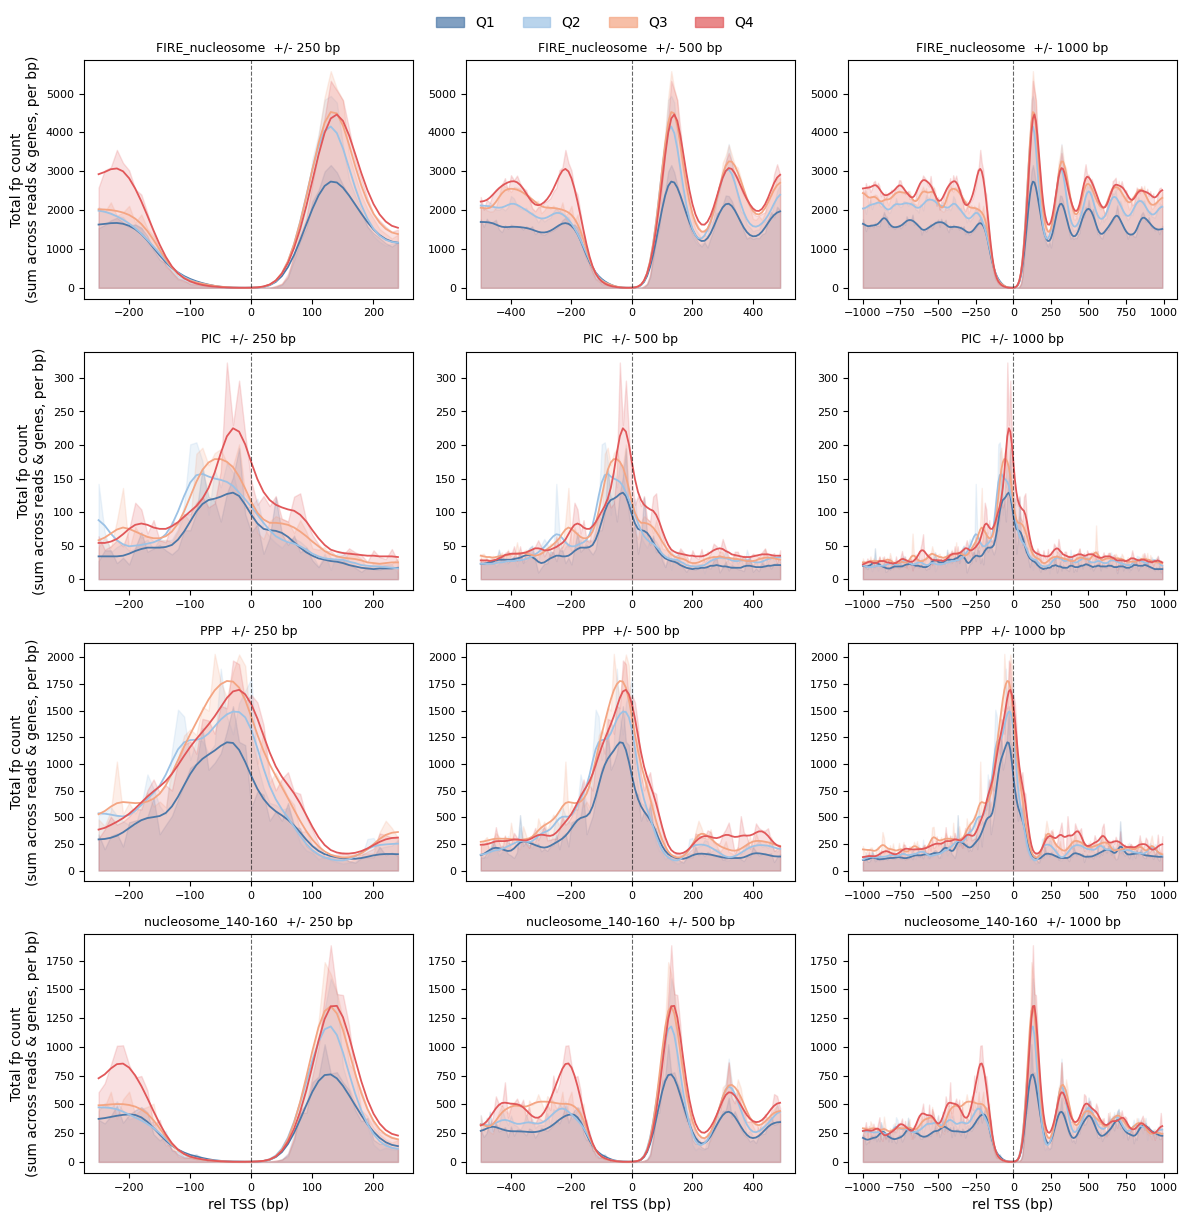

In [38]:
# Smoothed per-bp total count profile by quartile (light Gaussian smooth on the
# summed per-bp profile, raw total as filled area). Faceted by (footprint_type, window).
from scipy.ndimage import gaussian_filter1d

SMOOTH_SIGMA = 2  # bp; lower = sharper features, higher = smoother line

n_rows, n_cols = len(FP_TYPES), len(WINDOWS)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))

for i, fp_type in enumerate(FP_TYPES):
    for j, w in enumerate(WINDOWS):
        ax = axes[i, j]
        binned = fp_binned_by_config[(fp_type, w)]
        bin_cols, bin_centers = _bin_cols_centers(binned)
        for q in quartiles:
            sub = binned[binned["pi_quartile"] == q]
            total_profile = sub[bin_cols].sum(axis=0).to_numpy()
            smooth = gaussian_filter1d(total_profile, sigma=SMOOTH_SIGMA)
            ax.fill_between(bin_centers, total_profile, color=quartile_colors[q], alpha=0.18)
            ax.plot(bin_centers, smooth, color=quartile_colors[q], lw=1.3)
        ax.axvline(0, color="black", ls="--", lw=0.8, alpha=0.6)
        ax.set_title(f"{fp_type}  +/- {w} bp", fontsize=9)
        if i == n_rows - 1:
            ax.set_xlabel("rel TSS (bp)")
        if j == 0:
            ax.set_ylabel("Total fp count\n(sum across reads & genes, per bp)")
        ax.tick_params(labelsize=8)

handles = [mpatches.Patch(color=quartile_colors[q], alpha=0.7, label=q) for q in quartiles]
fig.legend(handles=handles, loc="upper center", ncol=len(quartiles),
           bbox_to_anchor=(0.5, 1.02), frameon=False)
plt.tight_layout()
fig.savefig(PLOT_OUT_DIR / "smoothed_total_profile_by_quartile_perbp.png", dpi=200, bbox_inches="tight")
plt.show()